In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from datetime import datetime

In [2]:
# configの読み込み
CONFIG_FILE = '../configs/config.yaml'
with open(CONFIG_FILE, encoding="utf-8") as file:
    yml = yaml.safe_load(file)

In [3]:
DIR_INPUT = yml["SETTING"]["DIR_INPUT"]
DIR_INTERIM = yml["SETTING"]["DIR_INTERIM"]
DIR_FEATURE = yml["SETTING"]["DIR_FEATURE"]
DIR_FIGURE = yml["SETTING"]["DIR_FIGURE"]
DIR_HOME = yml["SETTING"]["DIR_HOME"]
DIR_LOG = yml["SETTING"]["DIR_LOG"]
DIR_SUBMISSION = yml["SETTING"]["DIR_SUBMISSION"]
DIR_MODEL = yml["SETTING"]["DIR_MODEL"]
FILE_NAME_STATION = yml["SETTING"]["FILE_NAME_STATION"]
FILE_NAME_STATUS = yml["SETTING"]["FILE_NAME_STATUS"]
FILE_NAME_TRIP = yml["SETTING"]["FILE_NAME_TRIP"]
FILE_NAME_WEATHER = yml["SETTING"]["FILE_NAME_WEATHER"]

In [4]:
# 自作モジュールの読み込み
import sys
sys.path.append(DIR_HOME)
from src.runner import TimeseriesModelRunner, MLModelRunner
from src.model_LGBM import model_LGBM_multimodel, model_LGBM_multi_feat
from src.model_LSTM_mult import model_LSTM_mult
from src.model_ASMBL import model_ASMBL_demand_supply_intervention
from src.util import Logger, Util

/Users/ishizuka/opt/anaconda3/envs/mufgcup2024/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
def load_feature(file_name):
    file_name = file_name + ".pkl"
    return pd.read_pickle(os.path.join(DIR_FEATURE, file_name))

# LGBM_台数

In [151]:
# datasetの作成
df_main_lgb_bikes = load_feature("df_key")
df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_predict_add_valid_flag"), on=["station_id", "datetime"], how="left")
df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_bikes_available_fillna"), on=["station_id", "datetime"], how="left")
df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_bikes_available_lag"), on=["station_id", "datetime"], how="left")
df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_station_atr"), on=["station_id"], how="left")
df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_datetime_atr"), on=["datetime"], how="left")
# df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_weather_feat"), on=["datetime"], how="left")
# df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_bikes_available_rolling"), on=["station_id", "datetime"], how="left")
# df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_bikes_available_lr"), on=["station_id", "datetime"], how="left")
# df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_demand_lag"), on=["station_id", "datetime"], how="left")
# df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_supply_lag"), on=["station_id", "datetime"], how="left")
# df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_intervention_lag"), on=["station_id", "datetime"], how="left")
df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_demand_rolling"), on=["station_id", "datetime"], how="left")
df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_supply_rolling"), on=["station_id", "datetime"], how="left")
df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_intervention_rolling"), on=["station_id", "datetime"], how="left")
df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_demand_lr"), on=["station_id", "datetime"], how="left")
df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_supply_lr"), on=["station_id", "datetime"], how="left")
df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_intervention_lr"), on=["station_id", "datetime"], how="left")
df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_bikes_available_rate_lag"), on=["station_id", "datetime"], how="left")

In [40]:
# datasetの作成
df_main_lgb_bikes = load_feature("df_key")
df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_predict_add_valid_flag"), on=["station_id", "datetime"], how="left")
df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_bikes_available_trip_fillna"), on=["station_id", "datetime"], how="left")
df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_is_trip_fillna"), on=["station_id", "datetime"], how="left")
df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_bikes_available_trip_fillna_lag"), on=["station_id", "datetime"], how="left")
df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_station_atr"), on=["station_id"], how="left")
df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_datetime_atr"), on=["datetime"], how="left")

In [50]:
df_main_lgb_bikes = load_feature("df_key")
df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_predict_add_valid_flag"), on=["station_id", "datetime"], how="left")
df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_bikes_available_trip_fillna"), on=["station_id", "datetime"], how="left")

In [51]:
df_main_lgb_bikes.head()

,station_id,datetime,predict,bikes_available
0,0,2013-09-01 00:00:00,0,11.0
1,0,2013-09-01 01:00:00,0,11.0
2,0,2013-09-01 02:00:00,0,11.0
3,0,2013-09-01 03:00:00,0,11.0
4,0,2013-09-01 04:00:00,0,11.0


In [47]:
# df_main_lgb_bikes.to_pickle(os.path.join(DIR_FEATURE, "df_main_lgb_bikes.pkl"))
# df_main_lgb_bikes = pd.read_pickle(os.path.join(DIR_INTERIM, "df_main_lgb_new.pkl"))

In [57]:
import importlib
from src import runner
from src import model_LGBM
from src import model

# runnerモジュールをリロード
importlib.reload(runner)
importlib.reload(model_LGBM)
importlib.reload(model)

# Runnerクラスを再インポート
from src.model import Model
from src.runner import MLModelRunner
from src.model_LGBM import model_LGBM_multimodel, model_LGBM_multi_feat

In [53]:
# ロガーの設定
logger = Logger(path=DIR_LOG)

def get_run_name(model_type):
    """run名の作成
    """
    run_name = model_type
    suffix = '_' + datetime.now().strftime("%Y%m%d%H%M")
    run_name = run_name + suffix
    return run_name

# run_nameの設定
run_name = get_run_name(model_type="lgbm_multimodel_bikes")
# run_name = 'lgbm_multimodel_202410132324'
run_name

'lgbm_multimodel_bikes_202410242325'

In [54]:
def after_pred_func(df_pred, target_col):
    """予測後に行う処理
    Args:
        df_pred(pd.DataFrame): 予測データ[key_cols, 予測値]
    """
    # 負の値を0に変換
    df_pred[target_col] = df_pred[target_col].clip(lower=0)
    # dock_countを超えないようにする
    df_prep_station = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_station.pkl"))
    df_dock_count = df_prep_station[["station_id", "dock_count"]]
    df_pred = pd.merge(df_pred, df_dock_count, on="station_id", how="left", suffixes=("", "_"))
    df_pred[target_col] = df_pred[target_col].clip(upper=df_pred["dock_count"])
    return df_pred

model_params_lgb = {
    # run params
    "key_cols": ["datetime", "station_id"],
    "target_col": "bikes_available",
    "remove_cols": ["predict"],
    # model run params
    "num_boost_round": 5000,
    "early_stopping_rounds": 100,
    "verbose": 1,
    "period": 100,
    # model core params
    "boosting_type": "gbdt",
    "objective": "regression_l1",
    "metric": "l1",
    "learning_rate": 0.01,
    "lambda_l1": 0.1,
    "lambda_l2": 0.1,
    "feature_fraction": 0.8,
    # "num_leaves": 31,
    # "colsample_bytree": 0.5, # feature_fraction
    # "subsample": 0.5,
    # "reg_lambda": 5,
    # "random_state": 71,
    # 'max_depth': 3,
    # "min_data_in_leaf": 10,
    # "num_leaves": 31,
    # 'verbosity': -1,  # 出力を抑制
}
run_setting = {
    'calc_shap': False,     # shap値を計算するか否か
    'save_train_pred': False,    # trainデータに対する予測値を保存するか否か(閾値の最適化に使用)
    "tune_params": True,           # パラメータチューニング、lgb_hopt,xgb_hopt,nn_hopt,False
    "target_encoder": None, #TargetEncodingBlock(use_cache=False),     # target encodingをしない場合はNone
    "after_pred_func": after_pred_func,
}
cv_setting = {
    "key_cols": ["datetime", "station_id"],
    "target_col": "bikes_available",
    "initial_fold_date": "2014-09-01",
}

In [58]:
memo = "LightGBM23期マルチモデル 移動特徴量追加"
ml_runner = MLModelRunner(
    run_name,
    model_LGBM_multi_feat,
    model_params_lgb,
    df_main_lgb_bikes,
    run_setting,
    cv_setting,
    logger,
    memo)

In [56]:
ml_runner.run_train_cv()

[2024-10-24 23:26:19] - lgbm_multimodel_bikes_202410242325 - start training cv
[2024-10-24 23:26:19] - lgbm_multimodel_bikes_202410242325 fold 2014-09-01 - start training


max use train date : 2014-08-31 23:00:00
term: 1, tr_x: (22476, 134), tr_y: (22476, 1), va_x: (2170, 134), va_y: (2170, 1)
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015054 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7022
[LightGBM] [Info] Number of data points in the train set: 22476, number of used features: 133
[LightGBM] [Info] Start training from score 8.000000
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 1.30347	eval's l1: 1.46058
[200]	train's l1: 0.681663	eval's l1: 0.786841
[300]	train's l1: 0.466588	eval's l1: 0.538443
[400]	train's l1: 0.388275	eval's l1: 0.448038
[500]	train's l1: 0.349296	eval's l1: 0.400172
[600]	train's l1: 0.329322	eval's l1: 0.373381
[700]	train's l1: 0.318344	eval's l1: 0.357037
[800]	train's l1: 0.310881	eval's l1: 0.347521
[900]	train's l1: 0.305462	eval's l1: 0.341755
[1000]	train's l1: 0.302585	eval's l1: 0.338836
[11

[2024-10-24 23:31:29] - lgbm_multimodel_bikes_202410242325 fold 2014-09-01 - end training
[2024-10-24 23:31:29] - lgbm_multimodel_bikes_202410242325 fold 2014-10-01 - start training


max use train date : 2014-09-30 23:00:00
term: 1, tr_x: (24646, 134), tr_y: (24646, 1), va_x: (420, 134), va_y: (420, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004536 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7009
[LightGBM] [Info] Number of data points in the train set: 24646, number of used features: 133
[LightGBM] [Info] Start training from score 8.000000
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 1.31353	eval's l1: 1.34691
[200]	train's l1: 0.682496	eval's l1: 0.671339
[300]	train's l1: 0.469225	eval's l1: 0.435125
[400]	train's l1: 0.392248	eval's l1: 0.345769
[500]	train's l1: 0.356228	eval's l1: 0.299188
[600]	train's l1: 0.335827	eval's l1: 0.269317
[700]	train's l1: 0.320906	eval's l1: 0.246393
[800]	train's l1: 0.313137	eval's l1: 0.235175
[900]	train's l1: 0.307674	eval's l1

[2024-10-24 23:37:28] - lgbm_multimodel_bikes_202410242325 fold 2014-10-01 - end training
[2024-10-24 23:37:28] - lgbm_multimodel_bikes_202410242325 fold 2014-11-01 - start training


max use train date : 2014-10-31 23:00:00
term: 1, tr_x: (26746, 134), tr_y: (26746, 1), va_x: (420, 134), va_y: (420, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004683 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7135
[LightGBM] [Info] Number of data points in the train set: 26746, number of used features: 133
[LightGBM] [Info] Start training from score 8.000000
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 1.35401	eval's l1: 1.88919
[200]	train's l1: 0.746867	eval's l1: 1.21761
[300]	train's l1: 0.554663	eval's l1: 0.986397
[400]	train's l1: 0.466042	eval's l1: 0.82243
[500]	train's l1: 0.418931	eval's l1: 0.730697
[600]	train's l1: 0.392571	eval's l1: 0.682693
[700]	train's l1: 0.377421	eval's l1: 0.646789
[800]	train's l1: 0.368517	eval's l1: 0.625764
[900]	train's l1: 0.363433	eval's l1: 

In [39]:
ml_runner.run_metric_cv()

[2024-10-24 21:20:38] - lgbm_multimodel_bikes_202410242029 - start metric cv
  0%|          | 0/12 [00:00<?, ?it/s]

2014-09-01 00:00:00


  8%|▊         | 1/12 [00:11<02:06, 11.51s/it]

(8680, 3) (8680, 4)
2014-10-01 00:00:00


 17%|█▋        | 2/12 [00:22<01:53, 11.32s/it]

...

(6437, 3) (6437, 4)
2015-07-01 00:00:00


 92%|█████████▏| 11/12 [02:00<00:10, 10.83s/it]

(8050, 3) (8050, 4)
2015-08-01 00:00:00


100%|██████████| 12/12 [02:11<00:00, 10.96s/it]
memo: LightGBM23期マルチモデル 祝日追加 feature_fraction=0.8
run_name:lgbm_multimodel_bikes_202410242029	score_mean:1.5037543372302207	score0:1.5275750079680914	score1:1.729475352900187	score2:1.4869179746702528	score3:1.4997700393998137	score4:1.509316402712633	score5:1.3120075266653295	score6:1.525614159394479	score7:1.476450591720799	score8:1.4578369387691494	score9:1.5003515836380195	score10:1.5781660738514818	score11:1.4415703950724121
mean: 1.5037543372302207, std: 0.09190656337815328
[2024-10-24 21:22:50] - mean: 1.5037543372302207, std: 0.09190656337815328
[2024-10-24 21:22:50] - output predict : ../models/lgbm_multimodel_bikes_202410242029/va_pred.pkl
[2024-10-24 21:22:50] - lgbm_multimodel_bikes_202410242029 - end metric cv


(8050, 3) (8050, 4)


In [40]:
ml_runner.run_predict_cv()

[2024-10-24 21:22:50] - lgbm_multimodel_bikes_202410242029 - start prediction cv
100%|██████████| 12/12 [02:07<00:00, 10.60s/it]
[2024-10-24 21:24:57] - output predict : ../models/lgbm_multimodel_bikes_202410242029/te_pred.pkl
[2024-10-24 21:24:57] - lgbm_multimodel_bikes_202410242029 - end prediction cv


In [41]:
ml_runner.plot_feature_importance_cv()

[2024-10-24 21:24:57] - lgbm_multimodel_bikes_202410242029 - start plot feature importance cv
[2024-10-24 21:25:47] - lgbm_multimodel_bikes_202410242029 - end plot feature importance cv


In [42]:
# 予測値確認

In [43]:
path_va_pred = os.path.join(ml_runner.out_dir_name, "va_pred.pkl")
path_te_pred = os.path.join(ml_runner.out_dir_name, "te_pred.pkl")
df_va_pred = pd.read_pickle(path_va_pred)
df_te_pred = pd.read_pickle(path_te_pred)

df_true = pd.read_pickle(os.path.join(DIR_INTERIM, "status_data.pkl"))[ml_runner.key_cols+[ml_runner.target_col]]

In [ ]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-10-18"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_["bikes_available"], label="true")
plt.plot(df_["datetime"], df_["bikes_available_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_["bikes_available_te_pred"], label="te_pred")
plt.legend()
plt.show()

LightGBM23期マルチモデル 祝日追加 feature_fraction=0.8


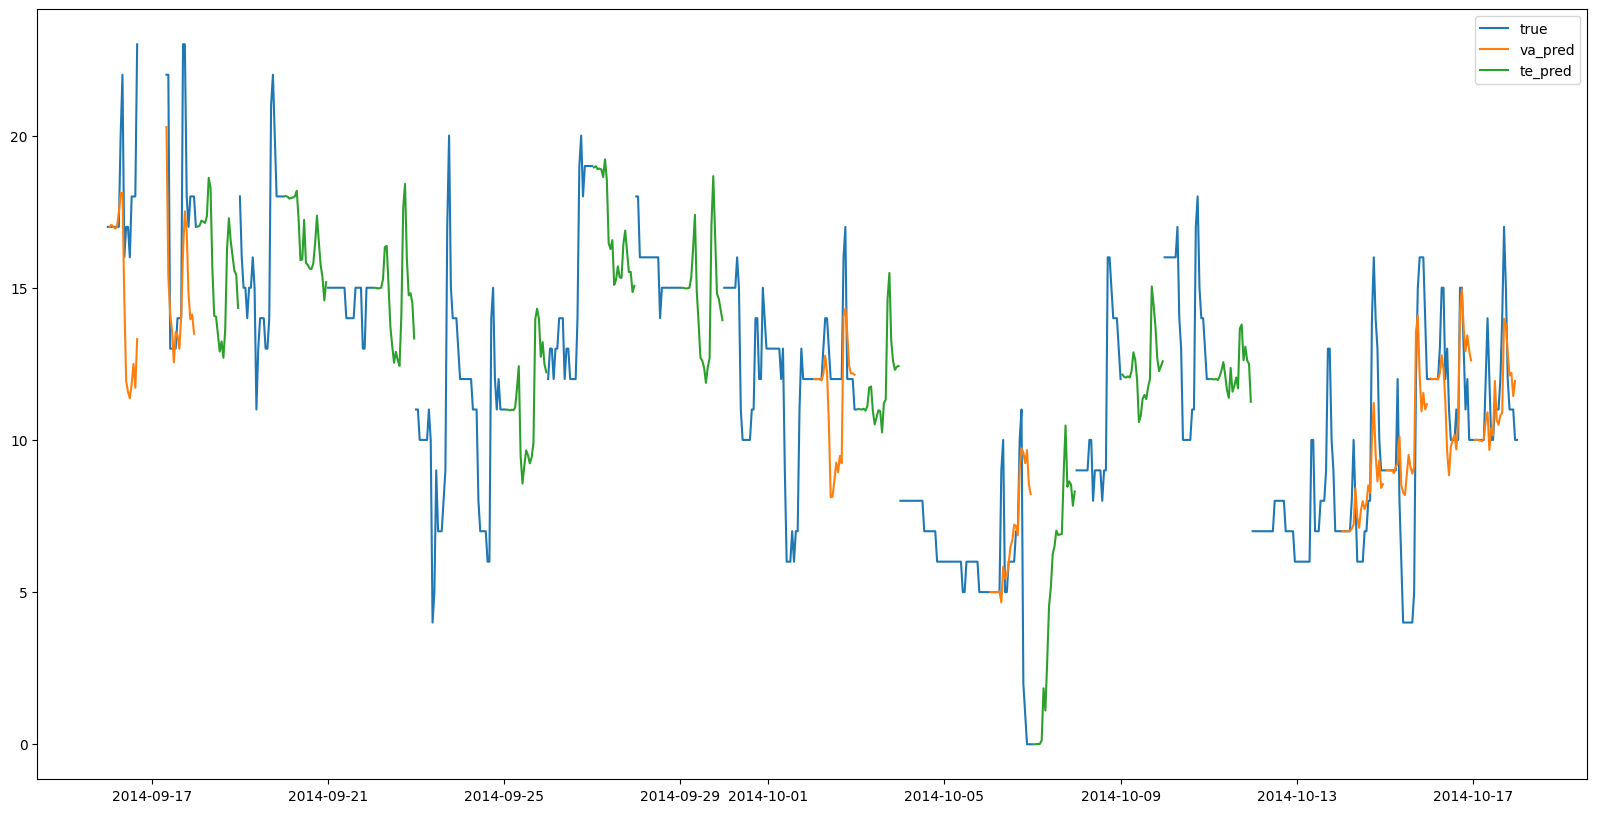

In [44]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-10-18"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_["bikes_available"], label="true")
plt.plot(df_["datetime"], df_["bikes_available_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_["bikes_available_te_pred"], label="te_pred")
plt.legend()
plt.show()

LightGBM23期マルチモデル 予測対象の時間によってデータを変える


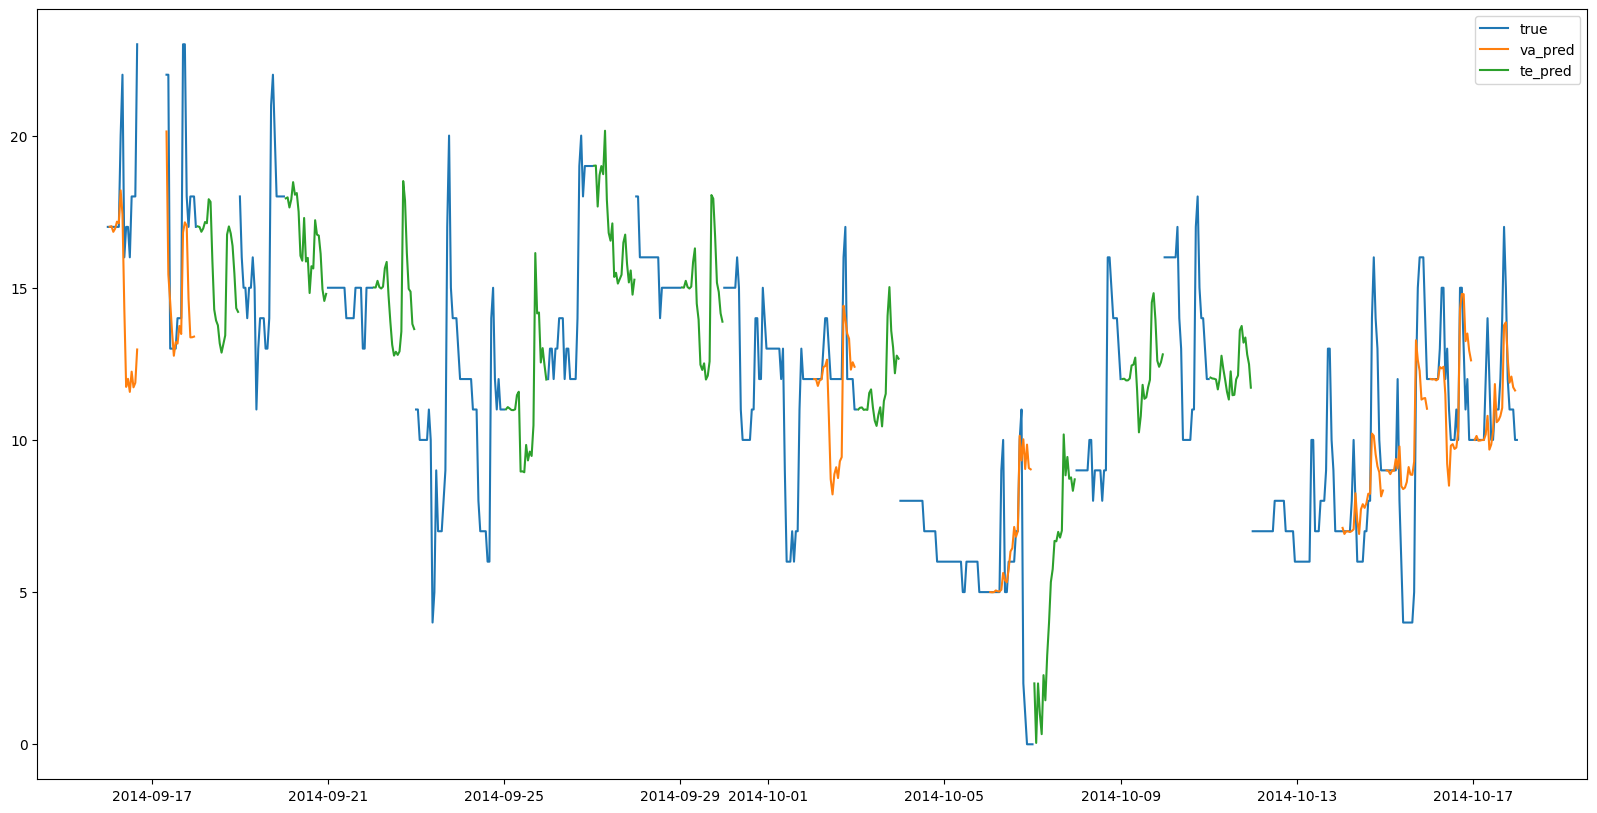

In [31]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-10-18"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_["bikes_available"], label="true")
plt.plot(df_["datetime"], df_["bikes_available_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_["bikes_available_te_pred"], label="te_pred")
plt.legend()
plt.show()

# LSTM_台数

In [ ]:
df_main_lstm_new = pd.read_pickle(os.path.join(DIR_INTERIM, "df_main_lstm_new.pkl"))

In [ ]:
df_main_lstm_new

,station_id,datetime,predict,bikes_available,weekday
0,0,2013-09-01 00:00:00,0,11.0,6
1,1,2013-09-01 00:00:00,0,8.0,6
2,2,2013-09-01 00:00:00,0,5.0,6
3,3,2013-09-01 00:00:00,0,9.0,6
4,4,2013-09-01 00:00:00,0,8.0,6
...,...,...,...,...,...
1226395,65,2015-08-31 23:00:00,0,13.0,0
1226396,66,2015-08-31 23:00:00,0,7.0,0
1226397,67,2015-08-31 23:00:00,0,6.0,0
1226398,68,2015-08-31 23:00:00,0,5.0,0


In [ ]:
# 自作モジュールの読み込み
import sys
sys.path.append(DIR_HOME)
from src.runner import TimeseriesModelRunner
from src.model_LSTM_mult import model_LSTM_mult
from datetime import datetime
from src.util import Logger

In [ ]:
import importlib
from src import runner
from src import model_LSTM_mult
from src import model

# runnerモジュールをリロード
importlib.reload(runner)
importlib.reload(model_LSTM_mult)
importlib.reload(model)

# Runnerクラスを再インポート
from src.runner import TimeseriesModelRunner
from src.model_LSTM_mult import model_LSTM_mult
from src.model import Model

In [ ]:
def get_run_name(model_type):
    """run名の作成
    """
    run_name = model_type
    suffix = '_' + datetime.now().strftime("%Y%m%d%H%M")
    run_name = run_name + suffix
    return run_name

In [ ]:
logger = Logger(path=DIR_LOG)

In [ ]:
run_name = get_run_name(model_type="lstm_mult")
# run_name = 'lstm_mult_202410132245'
run_name

'lstm_mult_202410181108'

In [ ]:
def after_pred_func(df_pred, target_col):
    """予測後に行う処理
    Args:
        df_pred(pd.DataFrame): 予測データ[key_cols, 予測値]
    """
    # 負の値を0に変換
    df_pred[target_col] = df_pred[target_col].clip(lower=0)
    # dock_countを超えないようにする
    df_prep_station = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_station.pkl"))
    df_dock_count = df_prep_station[["station_id", "dock_count"]]
    df_pred = pd.merge(df_pred, df_dock_count, on="station_id", how="left")
    df_pred[target_col] = df_pred[target_col].clip(upper=df_pred["dock_count"])
    return df_pred

In [ ]:
model_params = {
    "key_cols": ["datetime", "station_id"],
    "target_col": "bikes_available",
    "seq_length": 24,
    "n_steps": 23,
    "batch_size": 64,
    "shuffle": True,
    "hidden_size": 64,
    "num_epochs": 10,
    "learning_rate": 0.001,
}
run_setting = {
    'calc_shap': False,     # shap値を計算するか否か
    'save_train_pred': False,    # trainデータに対する予測値を保存するか否か(閾値の最適化に使用)
    "tune_params": True,           # パラメータチューニング、lgb_hopt,xgb_hopt,nn_hopt,False
    "target_encoder": None, #TargetEncodingBlock(use_cache=False),     # target encodingをしない場合はNone
    "after_pred_func": after_pred_func,
}
cv_setting = {
    "key_cols": ["datetime", "station_id"],
    "target_col": "bikes_available",
    "initial_fold_date": "2014-09-01",
}

In [ ]:
memo = "LSTMのマルチステップ予測 後処理追加"
timeseries_runner = TimeseriesModelRunner(run_name,
                                          model_LSTM_mult,
                                          model_params,
                                          df_main_lstm_new,
                                          run_setting,
                                          cv_setting,
                                          logger,
                                          memo)

In [ ]:
timeseries_runner.run_train_cv()

[2024-10-18 11:08:36] - lstm_mult_202410181108 - start training cv
[2024-10-18 11:08:36] - lstm_mult_202410181108 fold 2014-09-01 - start training


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
24576 24576
(24576, 24, 2) (24576, 23)
torch.Size([24576, 24, 2]) torch.Size([24576, 23])
24576
384
2
model
criterion


In [ ]:
timeseries_runner.run_metric_cv()

[2024-10-14 14:48:08] - lstm_mult_202410132245 - start metric cv
100%|██████████| 12/12 [00:23<00:00,  1.95s/it]
memo: LSTMのマルチステップ予測 後処理追加
run_name:lstm_mult_202410132245	score_mean:1.6819826614430216	score0:1.7368062295534643	score1:1.8970805470764205	score2:1.6028723657051864	score3:1.658505381214091	score4:1.6624859627015631	score5:1.5040819079485985	score6:1.702690100422395	score7:1.622700958258432	score8:1.617622394960939	score9:1.7418933251045943	score10:1.793829023956512	score11:1.6432237404140626
mean: 1.6819826614430216, std: 0.09738140548426347
[2024-10-14 14:48:31] - mean: 1.6819826614430216, std: 0.09738140548426347
[2024-10-14 14:48:31] - output predict : /Users/ishizuka/pyworks/Competitions/signate_mufgcup2024/models/lstm_mult_202410132245/va_pred.pkl
[2024-10-14 14:48:31] - lstm_mult_202410132245 - end metric cv


In [ ]:
timeseries_runner.run_predict_cv()

[2024-10-14 14:50:09] - lstm_mult_202410132245 - start prediction cv
100%|██████████| 12/12 [00:38<00:00,  3.17s/it]
[2024-10-14 14:50:48] - output predict : /Users/ishizuka/pyworks/Competitions/signate_mufgcup2024/models/lstm_mult_202410132245/te_pred.pkl
[2024-10-14 14:50:48] - lstm_mult_202410132245 - end prediction cv


In [ ]:
path_va_pred = os.path.join(timeseries_runner.out_dir_name, "va_pred.pkl")
path_te_pred = os.path.join(timeseries_runner.out_dir_name, "te_pred.pkl")
df_va_pred = pd.read_pickle(path_va_pred)
df_te_pred = pd.read_pickle(path_te_pred)

df_true = pd.read_pickle(os.path.join(DIR_INTERIM, "status_data.pkl"))[timeseries_runner.key_cols+[timeseries_runner.target_col]]

LSTMのマルチステップ予測 学習率0.001 epoch5


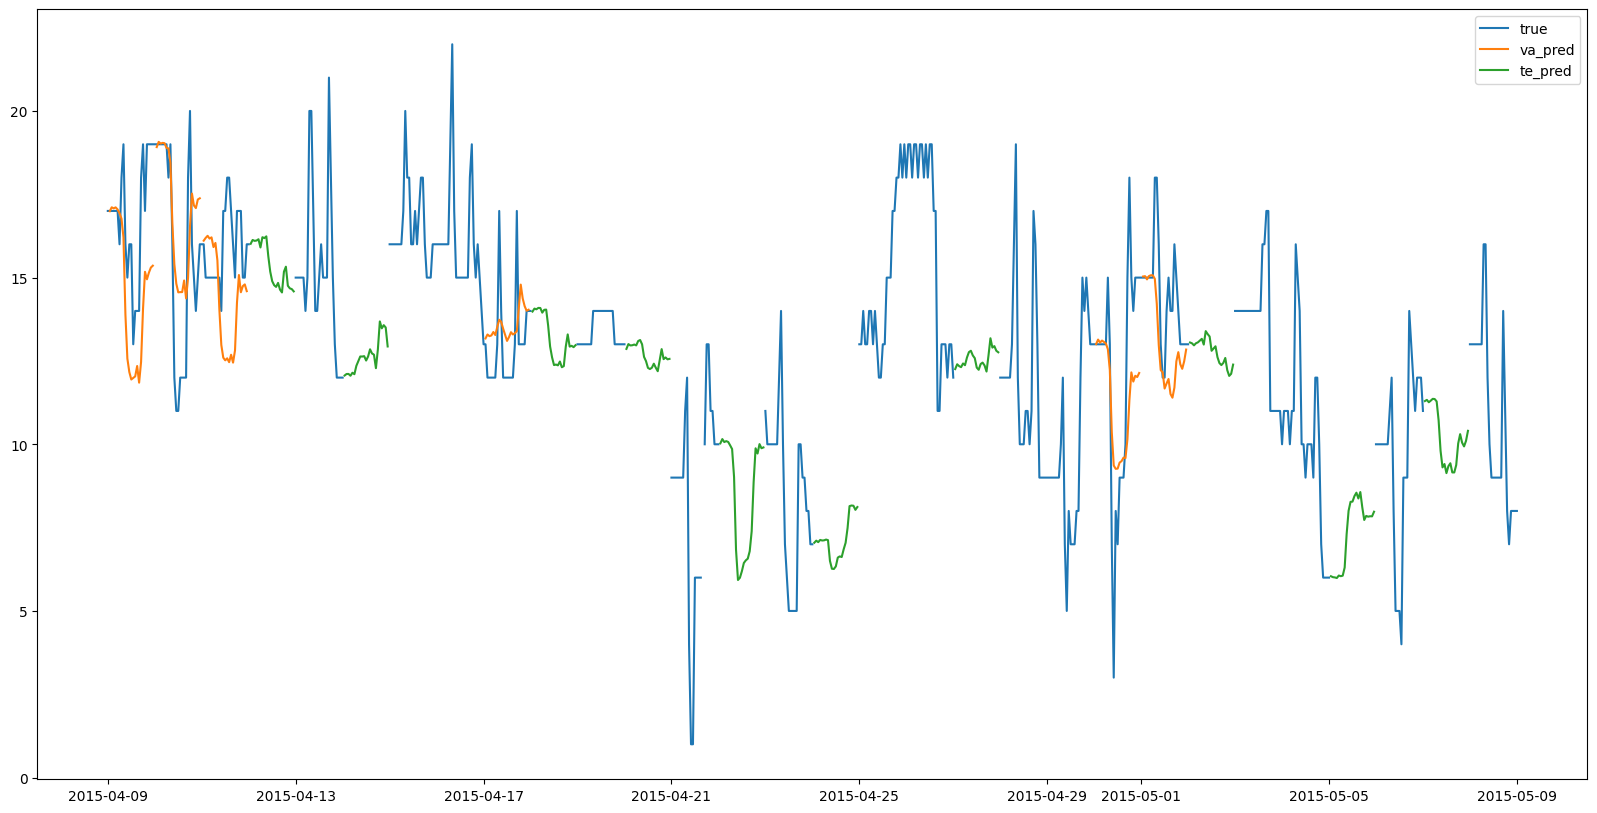

In [ ]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2015-04-09"
end_date = "2015-05-09"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_["bikes_available"], label="true")
plt.plot(df_["datetime"], df_["bikes_available_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_["bikes_available_te_pred"], label="te_pred")
plt.legend()
plt.show()

LSTMのマルチステップ予測 学習率0.001 epoch5


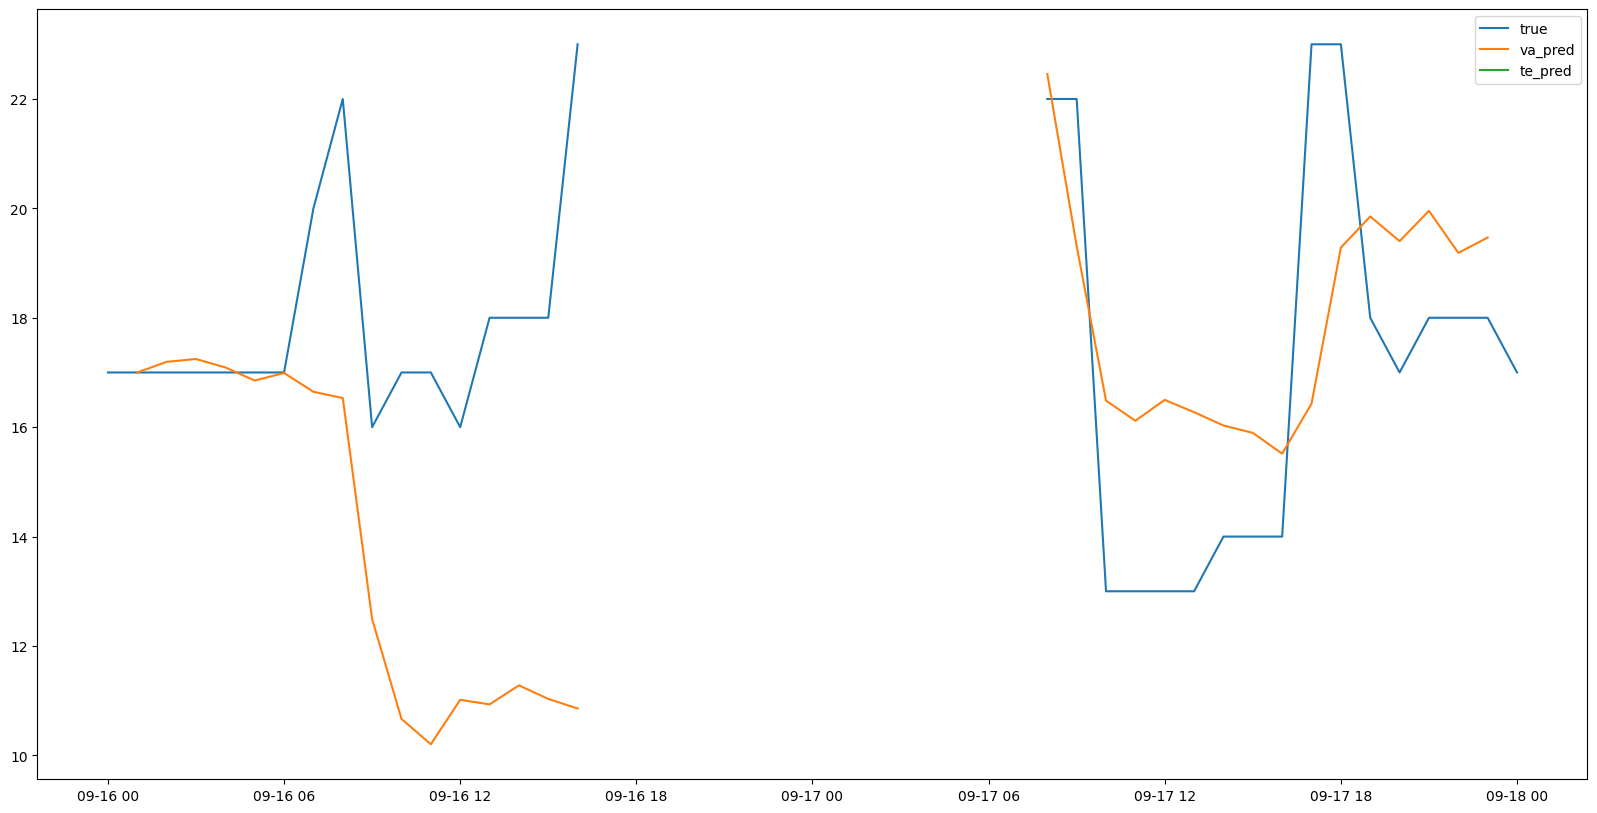

In [ ]:
# 元の目的関数が欠損している部分（）
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-09-18"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_["bikes_available"], label="true")
plt.plot(df_["datetime"], df_["bikes_available_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_["bikes_available_te_pred"], label="te_pred")
plt.legend()
plt.show()

In [ ]:
# 学習データ数の推移
for month in range(8, 13):
    i_fold = datetime(2014, month, 1)
    tr, tr_va_te, list_va_date, list_te_date = timeseries_runner.craete_train_valid_dateset(i_fold)
    model_ = model_LSTM_mult("sample", model_params, logger)
    self = model_
    feat_cols = [col for col in tr.columns.to_list() if col not in self.key_cols]
    x, y, list_key = self.create_sequences_for_forecast(tr, self.key_cols, feat_cols, self.seq_length, self.n_steps)
    print(i_fold, x.shape)

for month in range(1, 9):
    i_fold = datetime(2015, month, 1)
    tr, tr_va_te, list_va_date, list_te_date = timeseries_runner.craete_train_valid_dateset(i_fold)
    model_ = model_LSTM_mult("sample", model_params, logger)
    self = model_
    feat_cols = [col for col in tr.columns.to_list() if col not in self.key_cols]
    x, y, list_key = self.create_sequences_for_forecast(tr, self.key_cols, feat_cols, self.seq_length, self.n_steps)
    print(i_fold, x.shape)

2014-08-01 00:00:00 (22406, 24, 2)
2014-09-01 00:00:00 (24576, 24, 2)
2014-10-01 00:00:00 (25276, 24, 2)
2014-11-01 00:00:00 (26046, 24, 2)
2014-12-01 00:00:00 (26746, 24, 2)
2015-01-01 00:00:00 (27516, 24, 2)
2015-02-01 00:00:00 (28286, 24, 2)
2015-03-01 00:00:00 (28846, 24, 2)
2015-04-01 00:00:00 (29616, 24, 2)
2015-05-01 00:00:00 (30316, 24, 2)
2015-06-01 00:00:00 (31086, 24, 2)
2015-07-01 00:00:00 (31786, 24, 2)
2015-08-01 00:00:00 (32556, 24, 2)


# LGBM_需要

In [169]:

df_main_lgb_demand = load_feature("df_key")
df_main_lgb_demand = pd.merge(df_main_lgb_demand, load_feature("df_predict_add_valid_flag"), on=["station_id", "datetime"], how="left")
# df_main_lgb_demand = pd.merge(df_main_lgb_demand, load_feature("df_demand_cumsum"), on=["station_id", "datetime"], how="left")
df_main_lgb_demand = pd.merge(df_main_lgb_demand, load_feature("df_demand"), on=["station_id", "datetime"], how="left")
df_main_lgb_demand = pd.merge(df_main_lgb_demand, load_feature("df_demand_lag"), on=["station_id", "datetime"], how="left")
df_main_lgb_demand = pd.merge(df_main_lgb_demand, load_feature("df_supply_lag"), on=["station_id", "datetime"], how="left")
df_main_lgb_demand = pd.merge(df_main_lgb_demand, load_feature("df_intervention_lag"), on=["station_id", "datetime"], how="left")
df_main_lgb_demand = pd.merge(df_main_lgb_demand, load_feature("df_station_atr"), on=["station_id"], how="left")
df_main_lgb_demand = pd.merge(df_main_lgb_demand, load_feature("df_datetime_atr"), on=["datetime"], how="left")


In [170]:
df_main_lgb_demand.head()

,station_id,datetime,predict,demand,demand_lag0,demand_lag1,demand_lag2,demand_lag3,demand_lag4,demand_lag5,...,city_city3,city_city4,city_city5,datetime_feat,year,month,day,hour,weekday,holiday
0,0,2013-09-01 00:00:00,0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,0,0,0,20130901,2013,9,1,0,6,1
1,0,2013-09-01 01:00:00,0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,...,0,0,0,20130901,2013,9,1,1,6,1
2,0,2013-09-01 02:00:00,0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,...,0,0,0,20130901,2013,9,1,2,6,1
3,0,2013-09-01 03:00:00,0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,...,0,0,0,20130901,2013,9,1,3,6,1
4,0,2013-09-01 04:00:00,0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,...,0,0,0,20130901,2013,9,1,4,6,1


In [171]:
df_main_lgb_demand.to_pickle(os.path.join(DIR_FEATURE, "df_main_lgb_demand.pkl"))

In [172]:
import importlib
from src import runner
from src import model_LGBM
from src import model

# runnerモジュールをリロード
importlib.reload(runner)
importlib.reload(model_LGBM)
importlib.reload(model)

# Runnerクラスを再インポート
from src.model import Model
from src.runner import MLModelRunner
from src.model_LGBM import model_LGBM_multimodel

In [173]:
# ロガーの設定
logger = Logger(path=DIR_LOG)

def get_run_name(model_type):
    """run名の作成
    """
    run_name = model_type
    suffix = '_' + datetime.now().strftime("%Y%m%d%H%M")
    run_name = run_name + suffix
    return run_name

# run_nameの設定
run_name = get_run_name(model_type="lgbm_multiml_demand")
# run_name = 'lgbm_multiml_demand_202410142258'
run_name

'lgbm_multiml_demand_202410212351'

In [174]:
def after_pred_func(df_pred, target_col):
    """予測後に行う処理
    Args:
        df_pred(pd.DataFrame): 予測データ[key_cols, 予測値]
    """
    # 正の値を0に変換
    df_pred[target_col] = df_pred[target_col].clip(upper=0)

    return df_pred

In [175]:
model_params_lgb_demand = {
    # run params
    "key_cols": ["datetime", "station_id"],
    "target_col": "demand",
    "remove_cols": ["predict"],
    # model run params
    "num_boost_round": 3000,
    "early_stopping_rounds": 100,
    "verbose": 1,
    "period": 100,
    # model core params
    "boosting_type": "gbdt",
    "objective": "regression_l1",
    "metric": "l1",
    "learning_rate": 0.01,
    # "num_leaves": 31,
    # "colsample_bytree": 0.5, # feature_fraction
    # "subsample": 0.5,
    # "reg_lambda": 5,
    # "random_state": 71,
    # 'max_depth': 3,
    # "min_data_in_leaf": 10,
    # "num_leaves": 31,
    # 'verbosity': -1,  # 出力を抑制
}
run_setting_lgb_demand = {
    'calc_shap': False,     # shap値を計算するか否か
    'save_train_pred': False,    # trainデータに対する予測値を保存するか否か(閾値の最適化に使用)
    "tune_params": True,           # パラメータチューニング、lgb_hopt,xgb_hopt,nn_hopt,False
    "target_encoder": None, #TargetEncodingBlock(use_cache=False),     # target encodingをしない場合はNone
    "after_pred_func": after_pred_func,
}
cv_setting_lgb_demand = {
    "key_cols": ["datetime", "station_id"],
    "target_col": "demand",
    "initial_fold_date": "2014-09-01",
}

In [176]:
memo = "LightGBM23期マルチモデル demand"
ml_runner = MLModelRunner(
    run_name,
    model_LGBM_multimodel,
    model_params_lgb_demand,
    df_main_lgb_demand,
    run_setting_lgb_demand,
    cv_setting_lgb_demand,
    logger,
    memo)

In [177]:
ml_runner.run_train_cv()

[2024-10-21 23:52:41] - lgbm_multiml_demand_202410212351 - start training cv
[2024-10-21 23:52:41] - lgbm_multiml_demand_202410212351 fold 2014-09-01 - start training


term: 1, tr_x: (23380, 95), tr_y: (23380, 1), va_x: (2170, 95), va_y: (2170, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009196 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1855
[LightGBM] [Info] Number of data points in the train set: 23380, number of used features: 94
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 0.0450385	eval's l1: 0.0447005
Early stopping, best iteration is:
[1]	train's l1: 0.0450385	eval's l1: 0.0447005
term: 2, tr_x: (23380, 95), tr_y: (23380, 1), va_x: (2170, 95), va_y: (2170, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004989 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1855
[LightGBM] [Info] Number of data p

[2024-10-21 23:54:20] - lgbm_multiml_demand_202410212351 fold 2014-09-01 - end training
[2024-10-21 23:54:20] - lgbm_multiml_demand_202410212351 fold 2014-10-01 - start training


term: 1, tr_x: (25550, 95), tr_y: (25550, 1), va_x: (420, 95), va_y: (420, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007047 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1898
[LightGBM] [Info] Number of data points in the train set: 25550, number of used features: 94
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 0.045009	eval's l1: 0.0690476
Early stopping, best iteration is:
[1]	train's l1: 0.045009	eval's l1: 0.0690476
term: 2, tr_x: (25550, 95), tr_y: (25550, 1), va_x: (420, 95), va_y: (420, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012177 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1898
[LightGBM] [Info] Number of data points 

[2024-10-21 23:55:55] - lgbm_multiml_demand_202410212351 fold 2014-10-01 - end training
[2024-10-21 23:55:55] - lgbm_multiml_demand_202410212351 fold 2014-11-01 - start training


...

[2024-10-22 00:08:57] - lgbm_multiml_demand_202410212351 fold 2015-06-01 - end training
[2024-10-22 00:08:57] - lgbm_multiml_demand_202410212351 fold 2015-07-01 - start training


term: 1, tr_x: (44660, 95), tr_y: (44660, 1), va_x: (280, 95), va_y: (280, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011516 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2065
[LightGBM] [Info] Number of data points in the train set: 44660, number of used features: 94
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 0.0427436	eval's l1: 0.0178929
Early stopping, best iteration is:
[1]	train's l1: 0.042745	eval's l1: 0.0178929
term: 2, tr_x: (44660, 95), tr_y: (44660, 1), va_x: (280, 95), va_y: (280, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011656 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2065
[LightGBM] [Info] Number of data points

[2024-10-22 00:11:09] - lgbm_multiml_demand_202410212351 fold 2015-07-01 - end training
[2024-10-22 00:11:09] - lgbm_multiml_demand_202410212351 fold 2015-08-01 - start training


term: 1, tr_x: (46760, 95), tr_y: (46760, 1), va_x: (350, 95), va_y: (350, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011666 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2072
[LightGBM] [Info] Number of data points in the train set: 46760, number of used features: 94
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 0.0425323	eval's l1: 0.0428857
Early stopping, best iteration is:
[1]	train's l1: 0.0425342	eval's l1: 0.0428857
term: 2, tr_x: (46760, 95), tr_y: (46760, 1), va_x: (350, 95), va_y: (350, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014075 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2072
[LightGBM] [Info] Number of data point

[2024-10-22 00:13:11] - lgbm_multiml_demand_202410212351 fold 2015-08-01 - end training
[2024-10-22 00:13:11] - lgbm_multiml_demand_202410212351 - end training cv


In [178]:
ml_runner.run_metric_cv()

[2024-10-22 00:13:12] - lgbm_multiml_demand_202410212351 - start metric cv
  0%|          | 0/12 [00:00<?, ?it/s]

2014-09-01 00:00:00


  8%|▊         | 1/12 [00:23<04:13, 23.07s/it]

(9660, 3) (9660, 3)
2014-10-01 00:00:00


 17%|█▋        | 2/12 [00:43<03:36, 21.60s/it]

...

(6440, 3) (6440, 3)
2015-07-01 00:00:00


 92%|█████████▏| 11/12 [03:41<00:19, 19.11s/it]

(8050, 3) (8050, 3)
2015-08-01 00:00:00


100%|██████████| 12/12 [03:59<00:00, 19.99s/it]
memo: LightGBM23期マルチモデル demand
run_name:lgbm_multiml_demand_202410212351	score_mean:0.42288585478000557	score0:0.4347177557544035	score1:0.49230941645363285	score2:0.42927597874164014	score3:0.30551814673413497	score4:0.4782047608180375	score5:0.3847723751421817	score6:0.39684449728277166	score7:0.41130210027920794	score8:0.382540149297256	score9:0.5041537348250549	score10:0.4399436281131027	score11:0.41504771391864326
mean: 0.42288585478000557, std: 0.052189909702810164
[2024-10-22 00:17:12] - mean: 0.42288585478000557, std: 0.052189909702810164
[2024-10-22 00:17:12] - output predict : ../models/lgbm_multiml_demand_202410212351/va_pred.pkl
[2024-10-22 00:17:12] - lgbm_multiml_demand_202410212351 - end metric cv


(8050, 3) (8050, 3)


In [179]:
ml_runner.run_predict_cv()

[2024-10-22 00:17:12] - lgbm_multiml_demand_202410212351 - start prediction cv
100%|██████████| 12/12 [03:36<00:00, 18.07s/it]
[2024-10-22 00:20:48] - output predict : ../models/lgbm_multiml_demand_202410212351/te_pred.pkl
[2024-10-22 00:20:48] - lgbm_multiml_demand_202410212351 - end prediction cv


In [180]:
ml_runner.plot_feature_importance_cv()

[2024-10-22 00:20:49] - lgbm_multiml_demand_202410212351 - start plot feature importance cv
[2024-10-22 00:21:29] - lgbm_multiml_demand_202410212351 - end plot feature importance cv


In [181]:
path_va_pred = os.path.join(ml_runner.out_dir_name, "va_pred.pkl")
path_te_pred = os.path.join(ml_runner.out_dir_name, "te_pred.pkl")
df_va_pred = pd.read_pickle(path_va_pred)
df_te_pred = pd.read_pickle(path_te_pred)

df_true = df_main_lgb_demand[ml_runner.key_cols+[ml_runner.target_col]]

LightGBM23期マルチモデル demand


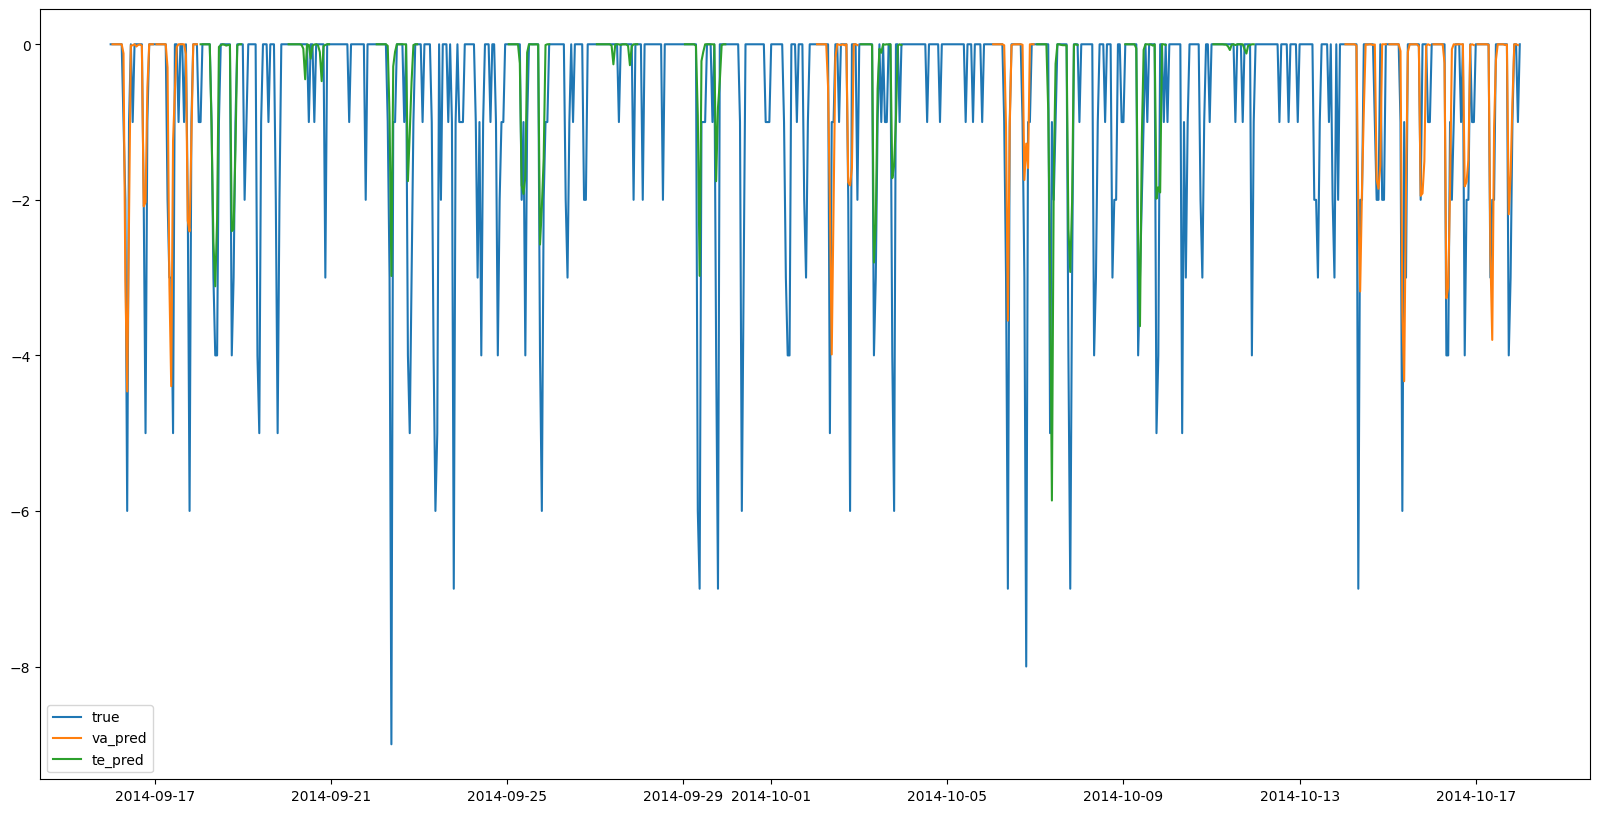

In [182]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-10-18"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}"], label="true")
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}_te_pred"], label="te_pred")
plt.legend()
plt.show()

LightGBM23期マルチモデル demand_cumsum


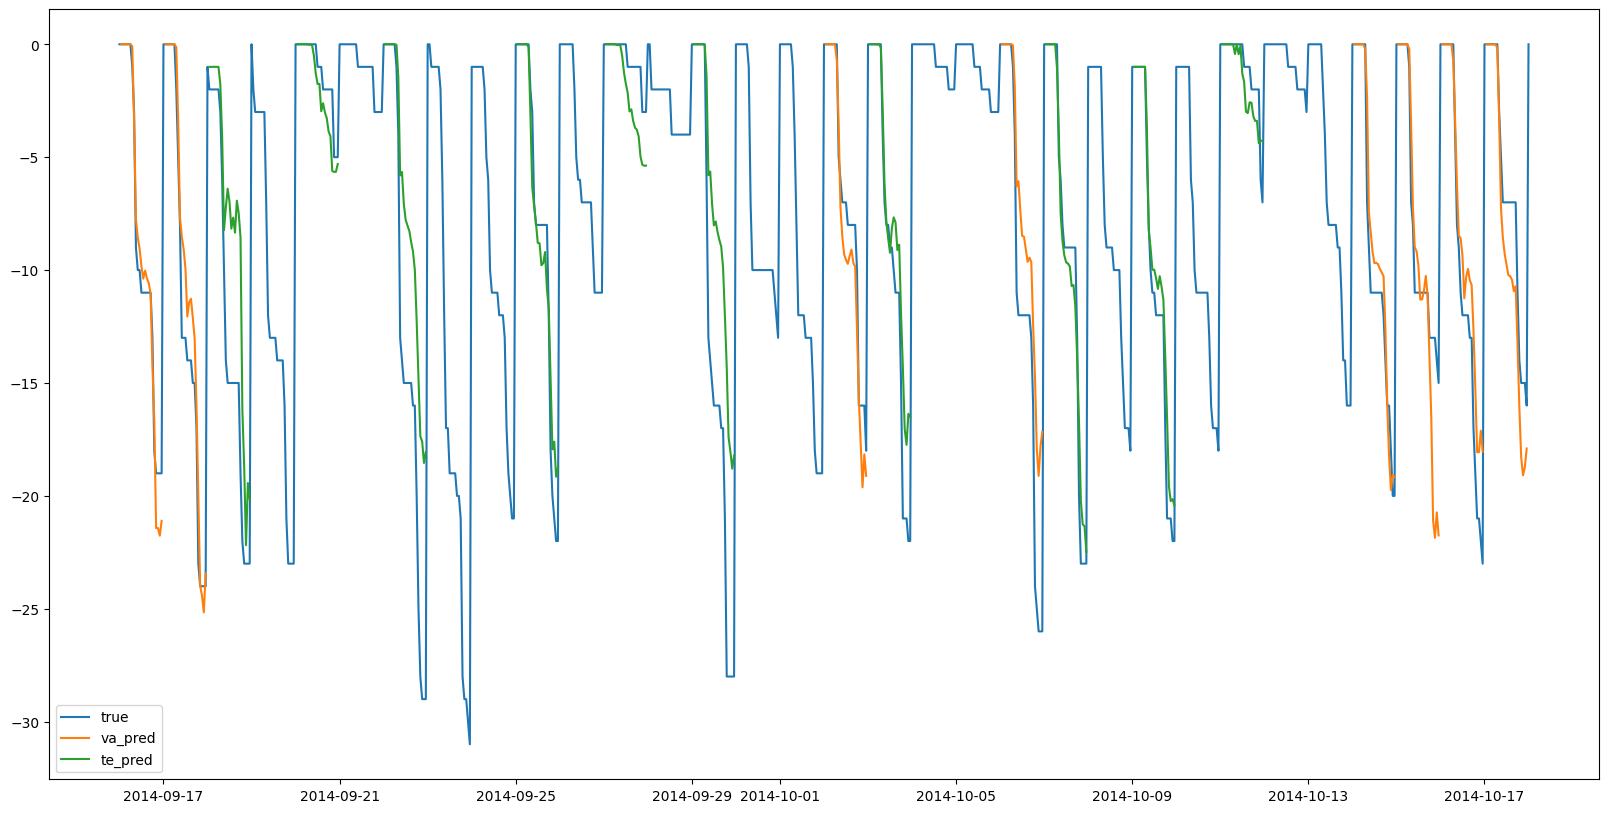

In [83]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-10-18"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}"], label="true")
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}_te_pred"], label="te_pred")
plt.legend()
plt.show()

LightGBM23期マルチモデル demand_cumsum


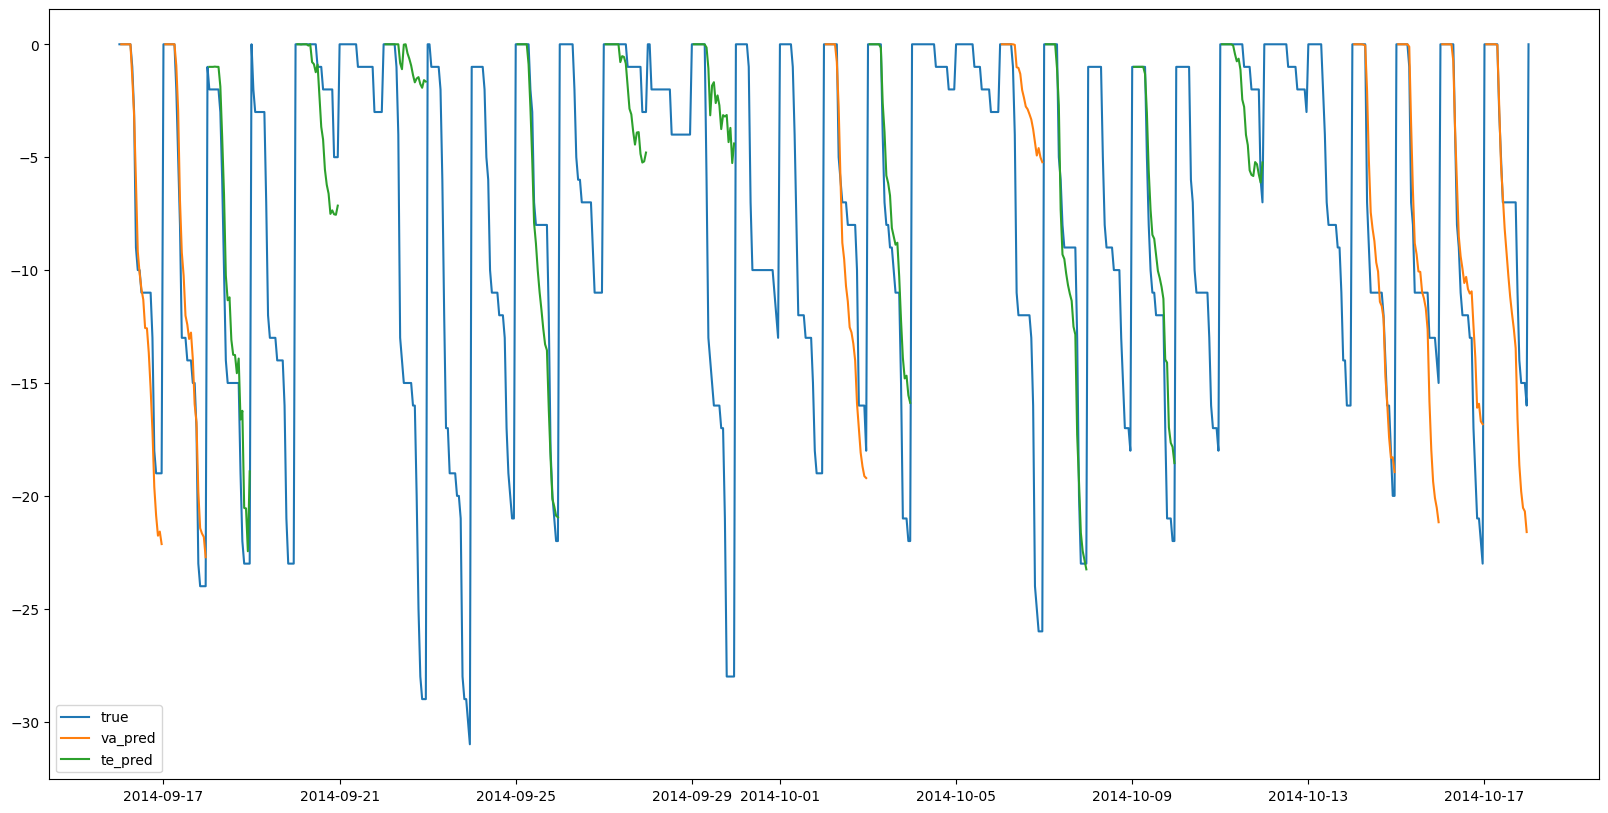

In [ ]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-10-18"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}"], label="true")
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}_te_pred"], label="te_pred")
plt.legend()
plt.show()

# LGBM_供給

In [183]:
df_main_lgb_supply = load_feature("df_key")
df_main_lgb_supply = pd.merge(df_main_lgb_supply, load_feature("df_predict_add_valid_flag"), on=["station_id", "datetime"], how="left")
# df_main_lgb_supply = pd.merge(df_main_lgb_supply, load_feature("df_supply_cumsum"), on=["station_id", "datetime"], how="left")
df_main_lgb_supply = pd.merge(df_main_lgb_supply, load_feature("df_supply"), on=["station_id", "datetime"], how="left")
df_main_lgb_supply = pd.merge(df_main_lgb_supply, load_feature("df_supply_lag"), on=["station_id", "datetime"], how="left")
df_main_lgb_demand = pd.merge(df_main_lgb_demand, load_feature("df_demand_lag"), on=["station_id", "datetime"], how="left")
df_main_lgb_demand = pd.merge(df_main_lgb_demand, load_feature("df_supply_lag"), on=["station_id", "datetime"], how="left")
df_main_lgb_demand = pd.merge(df_main_lgb_demand, load_feature("df_intervention_lag"), on=["station_id", "datetime"], how="left")
df_main_lgb_demand = pd.merge(df_main_lgb_demand, load_feature("df_station_atr"), on=["station_id"], how="left")
df_main_lgb_demand = pd.merge(df_main_lgb_demand, load_feature("df_datetime_atr"), on=["datetime"], how="left")

In [184]:
df_main_lgb_supply.to_pickle(os.path.join(DIR_FEATURE, "df_main_lgb_supply.pkl"))

In [185]:
import importlib
from src import runner
from src import model_LGBM
from src import model

# runnerモジュールをリロード
importlib.reload(runner)
importlib.reload(model_LGBM)
importlib.reload(model)

# Runnerクラスを再インポート
from src.model import Model
from src.runner import MLModelRunner
from src.model_LGBM import model_LGBM_multimodel

In [186]:
# ロガーの設定
logger = Logger(path=DIR_LOG)

def get_run_name(model_type):
    """run名の作成
    """
    run_name = model_type
    suffix = '_' + datetime.now().strftime("%Y%m%d%H%M")
    run_name = run_name + suffix
    return run_name

# run_nameの設定
run_name = get_run_name(model_type="lgbm_multiml_supply")
# run_name = 'lgbm_multiml_demand_202410142258'
run_name

'lgbm_multiml_supply_202410220021'

In [187]:
def after_pred_func(df_pred, target_col):
    """予測後に行う処理
    Args:
        df_pred(pd.DataFrame): 予測データ[key_cols, 予測値]
    """
    # 正の値を0に変換
    df_pred[target_col] = df_pred[target_col].clip(lower=0)

    return df_pred

model_params_lgb_supply = {
    # run params
    "key_cols": ["datetime", "station_id"],
    "target_col": "supply",
    "remove_cols": ["predict"],
    # model run params
    "num_boost_round": 3000,
    "early_stopping_rounds": 100,
    "verbose": 1,
    "period": 100,
    # model core params
    "boosting_type": "gbdt",
    "objective": "regression_l1",
    "metric": "l1",
    "learning_rate": 0.01,
    # "num_leaves": 31,
    # "colsample_bytree": 0.5, # feature_fraction
    # "subsample": 0.5,
    # "reg_lambda": 5,
    # "random_state": 71,
    # 'max_depth': 3,
    # "min_data_in_leaf": 10,
    # "num_leaves": 31,
    # 'verbosity': -1,  # 出力を抑制
}
run_setting_lgb_supply = {
    'calc_shap': False,     # shap値を計算するか否か
    'save_train_pred': False,    # trainデータに対する予測値を保存するか否か(閾値の最適化に使用)
    "tune_params": True,           # パラメータチューニング、lgb_hopt,xgb_hopt,nn_hopt,False
    "target_encoder": None, #TargetEncodingBlock(use_cache=False),     # target encodingをしない場合はNone
    "after_pred_func": after_pred_func,
}
cv_setting_lgb_supply = {
    "key_cols": ["datetime", "station_id"],
    "target_col": "supply",
    "initial_fold_date": "2014-09-01",
}

In [188]:
memo = "LightGBM23期マルチモデル supply"
ml_runner = MLModelRunner(
    run_name,
    model_LGBM_multimodel,
    model_params_lgb_supply,
    df_main_lgb_supply,
    run_setting_lgb_supply,
    cv_setting_lgb_supply,
    logger,
    memo)

In [189]:
ml_runner.run_train_cv()

[2024-10-22 00:21:48] - lgbm_multiml_supply_202410220021 - start training cv
[2024-10-22 00:21:49] - lgbm_multiml_supply_202410220021 fold 2014-09-01 - start training


term: 1, tr_x: (23380, 25), tr_y: (23380, 1), va_x: (2170, 25), va_y: (2170, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003739 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 357
[LightGBM] [Info] Number of data points in the train set: 23380, number of used features: 25
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 0.0523952	eval's l1: 0.0562212
Early stopping, best iteration is:
[1]	train's l1: 0.0523952	eval's l1: 0.0562212
term: 2, tr_x: (23380, 25), tr_y: (23380, 1), va_x: (2170, 25), va_y: (2170, 1)
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009741 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 357
[LightGBM] [Info] Number of data points in the train set: 23380, number of used features: 25
Trainin

[2024-10-22 00:23:01] - lgbm_multiml_supply_202410220021 fold 2014-09-01 - end training
[2024-10-22 00:23:01] - lgbm_multiml_supply_202410220021 fold 2014-10-01 - start training


term: 1, tr_x: (25550, 25), tr_y: (25550, 1), va_x: (420, 25), va_y: (420, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003440 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 373
[LightGBM] [Info] Number of data points in the train set: 25550, number of used features: 25
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 0.0527202	eval's l1: 0.0642857
Early stopping, best iteration is:
[1]	train's l1: 0.0527202	eval's l1: 0.0642857
term: 2, tr_x: (25550, 25), tr_y: (25550, 1), va_x: (420, 25), va_y: (420, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003099 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 373
[LightGBM] [Info] Number of data points 

[2024-10-22 00:24:13] - lgbm_multiml_supply_202410220021 fold 2014-10-01 - end training
[2024-10-22 00:24:13] - lgbm_multiml_supply_202410220021 fold 2014-11-01 - start training


...

[2024-10-22 00:31:17] - lgbm_multiml_supply_202410220021 fold 2015-06-01 - end training
[2024-10-22 00:31:17] - lgbm_multiml_supply_202410220021 fold 2015-07-01 - start training


term: 1, tr_x: (44660, 25), tr_y: (44660, 1), va_x: (280, 25), va_y: (280, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003899 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 411
[LightGBM] [Info] Number of data points in the train set: 44660, number of used features: 25
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 0.0512987	eval's l1: 0.0214286
Early stopping, best iteration is:
[1]	train's l1: 0.0512987	eval's l1: 0.0214286
term: 2, tr_x: (44660, 25), tr_y: (44660, 1), va_x: (280, 25), va_y: (280, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003817 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 411
[LightGBM] [Info] Number of data points 

[2024-10-22 00:32:10] - lgbm_multiml_supply_202410220021 fold 2015-07-01 - end training
[2024-10-22 00:32:10] - lgbm_multiml_supply_202410220021 fold 2015-08-01 - start training


term: 1, tr_x: (46760, 25), tr_y: (46760, 1), va_x: (350, 25), va_y: (350, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004653 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 414
[LightGBM] [Info] Number of data points in the train set: 46760, number of used features: 25
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 0.0508127	eval's l1: 0.0571429
Early stopping, best iteration is:
[1]	train's l1: 0.0508127	eval's l1: 0.0571429
term: 2, tr_x: (46760, 25), tr_y: (46760, 1), va_x: (350, 25), va_y: (350, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003292 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 414
[LightGBM] [Info] Number of data points 

[2024-10-22 00:32:58] - lgbm_multiml_supply_202410220021 fold 2015-08-01 - end training
[2024-10-22 00:32:58] - lgbm_multiml_supply_202410220021 - end training cv


In [190]:
ml_runner.run_metric_cv()

[2024-10-22 00:32:58] - lgbm_multiml_supply_202410220021 - start metric cv
  0%|          | 0/12 [00:00<?, ?it/s]

2014-09-01 00:00:00


  8%|▊         | 1/12 [00:14<02:34, 14.04s/it]

(9660, 3) (9660, 3)
2014-10-01 00:00:00


 17%|█▋        | 2/12 [00:27<02:15, 13.50s/it]

...

(6440, 3) (6440, 3)
2015-07-01 00:00:00


 92%|█████████▏| 11/12 [02:26<00:13, 13.24s/it]

(8050, 3) (8050, 3)
2015-08-01 00:00:00


100%|██████████| 12/12 [02:39<00:00, 13.29s/it]
memo: LightGBM23期マルチモデル supply
run_name:lgbm_multiml_supply_202410220021	score_mean:0.49194865322429315	score0:0.5399024053076272	score1:0.5454867749819262	score2:0.4743654048436148	score3:0.3409258862717323	score4:0.5036673033989183	score5:0.45105923245965934	score6:0.5003702298123868	score7:0.46659617497874534	score8:0.4302029190773277	score9:0.5943581211475248	score10:0.5595733064111819	score11:0.49687608000087335
mean: 0.49194865322429315, std: 0.06435804161005862
[2024-10-22 00:35:38] - mean: 0.49194865322429315, std: 0.06435804161005862
[2024-10-22 00:35:38] - output predict : ../models/lgbm_multiml_supply_202410220021/va_pred.pkl
[2024-10-22 00:35:38] - lgbm_multiml_supply_202410220021 - end metric cv


(8050, 3) (8050, 3)


In [191]:
ml_runner.run_predict_cv()

[2024-10-22 00:35:38] - lgbm_multiml_supply_202410220021 - start prediction cv
100%|██████████| 12/12 [02:42<00:00, 13.57s/it]
[2024-10-22 00:38:21] - output predict : ../models/lgbm_multiml_supply_202410220021/te_pred.pkl
[2024-10-22 00:38:21] - lgbm_multiml_supply_202410220021 - end prediction cv


In [192]:
ml_runner.plot_feature_importance_cv()

[2024-10-22 00:38:21] - lgbm_multiml_supply_202410220021 - start plot feature importance cv
[2024-10-22 00:38:51] - lgbm_multiml_supply_202410220021 - end plot feature importance cv


In [193]:
path_va_pred = os.path.join(ml_runner.out_dir_name, "va_pred.pkl")
path_te_pred = os.path.join(ml_runner.out_dir_name, "te_pred.pkl")
df_va_pred = pd.read_pickle(path_va_pred)
df_te_pred = pd.read_pickle(path_te_pred)

df_true = df_main_lgb_supply[ml_runner.key_cols+[ml_runner.target_col]]

LightGBM23期マルチモデル supply


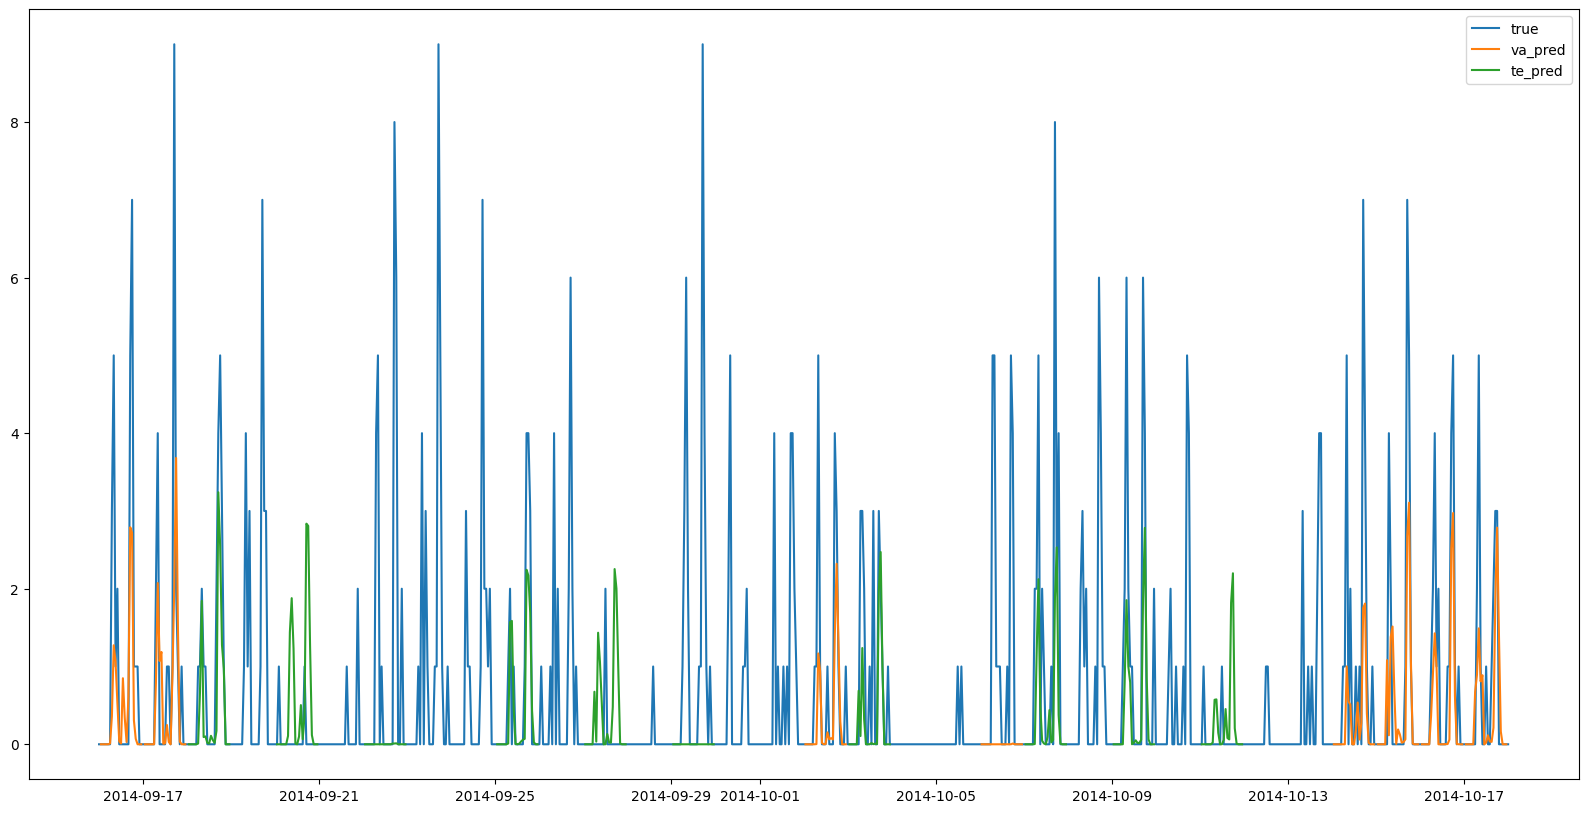

In [194]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-10-18"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}"], label="true")
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}_te_pred"], label="te_pred")
plt.legend()
plt.show()

LightGBM23期マルチモデル supply_cumsum


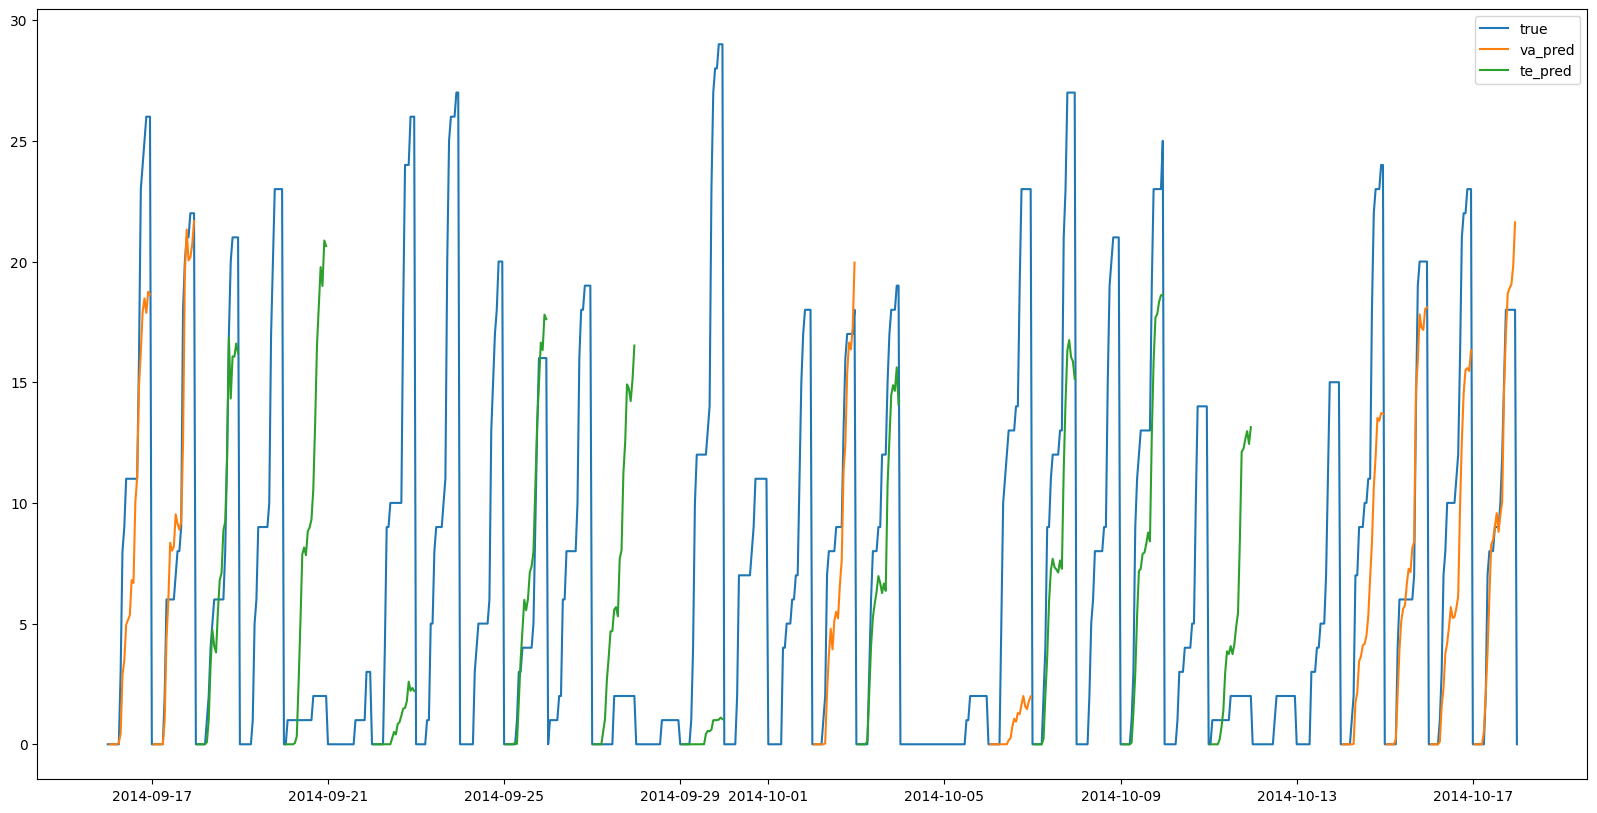

In [94]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-10-18"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}"], label="true")
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}_te_pred"], label="te_pred")
plt.legend()
plt.show()

LightGBM23期マルチモデル demand_supply


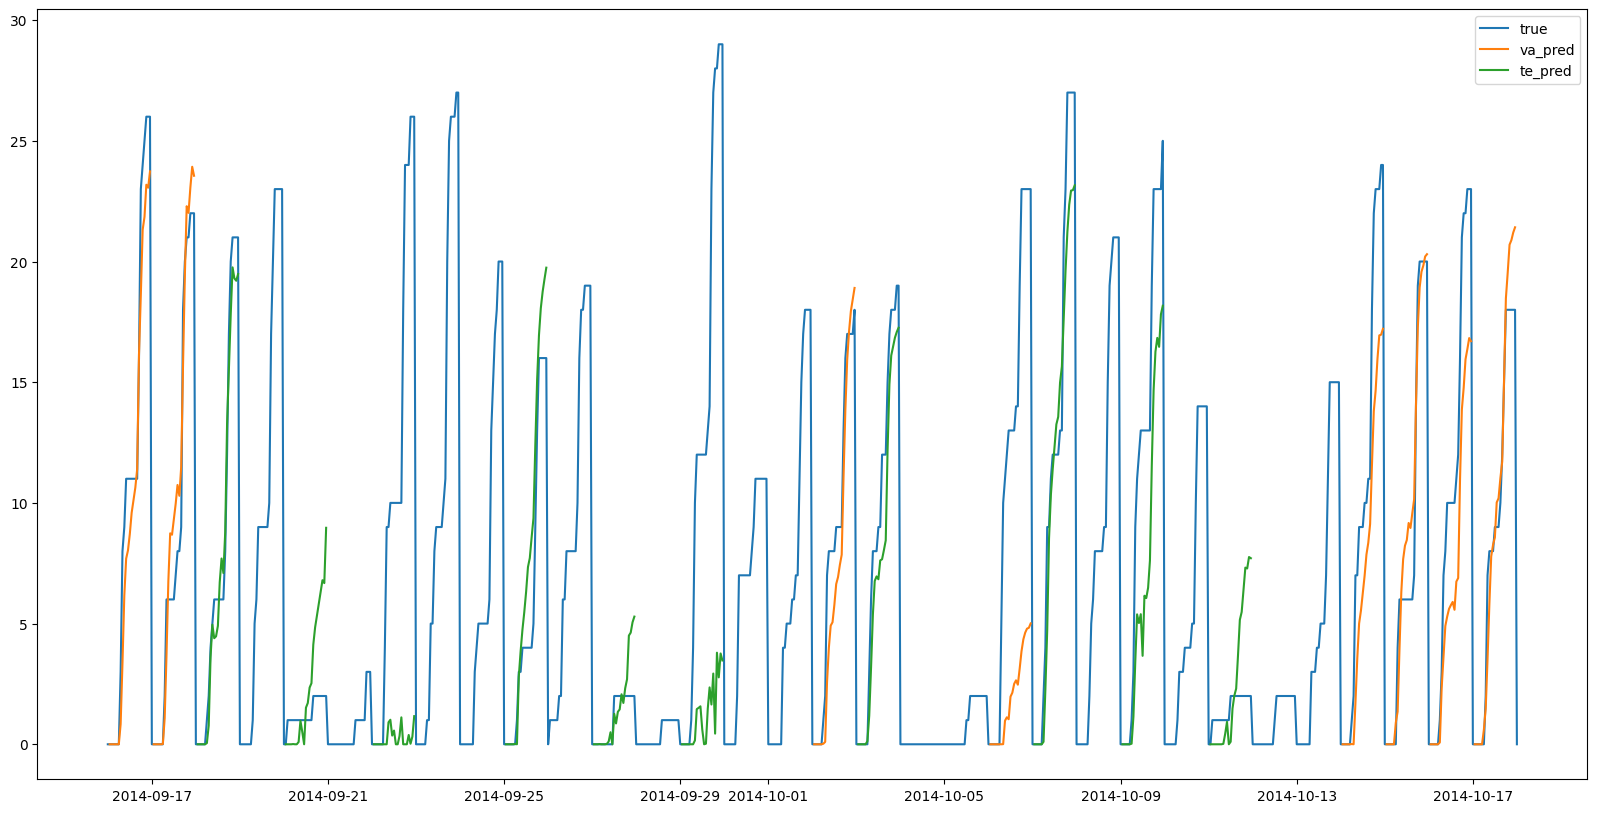

In [ ]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-10-18"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}"], label="true")
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}_te_pred"], label="te_pred")
plt.legend()
plt.show()

# LGBM_介入

In [21]:
df_main_lgb_intervention = load_feature("df_key")
df_main_lgb_intervention = pd.merge(df_main_lgb_intervention, load_feature("df_predict_add_valid_flag"), on=["station_id", "datetime"], how="left")
# df_main_lgb_intervention = pd.merge(df_main_lgb_intervention, load_feature("df_intervention_cumsum"), on=["station_id", "datetime"], how="left")
df_main_lgb_intervention = pd.merge(df_main_lgb_intervention, load_feature("df_intervention"), on=["station_id", "datetime"], how="left")
df_main_lgb_intervention = pd.merge(df_main_lgb_intervention, load_feature("df_demand_lag"), on=["station_id", "datetime"], how="left")
df_main_lgb_intervention = pd.merge(df_main_lgb_intervention, load_feature("df_supply_lag"), on=["station_id", "datetime"], how="left")
df_main_lgb_intervention = pd.merge(df_main_lgb_intervention, load_feature("df_intervention_lag"), on=["station_id", "datetime"], how="left")
df_main_lgb_intervention = pd.merge(df_main_lgb_intervention, load_feature("df_station_atr"), on=["station_id"], how="left")
df_main_lgb_intervention = pd.merge(df_main_lgb_intervention, load_feature("df_datetime_atr"), on=["datetime"], how="left")
df_main_lgb_intervention = pd.merge(df_main_lgb_intervention, load_feature("df_bikes_available_rate_lag"), on=["station_id", "datetime"], how="left")

In [22]:
df_main_lgb_intervention.to_pickle(os.path.join(DIR_FEATURE, "df_main_lgb_intervention.pkl"))

In [45]:
import importlib
from src import runner
from src import model_LGBM
from src import model

# runnerモジュールをリロード
importlib.reload(runner)
importlib.reload(model_LGBM)
importlib.reload(model)

# Runnerクラスを再インポート
from src.model import Model
from src.runner import MLModelRunner
from src.model_LGBM import model_LGBM_multimodel

In [24]:
# ロガーの設定
logger = Logger(path=DIR_LOG)

def get_run_name(model_type):
    """run名の作成
    """
    run_name = model_type
    suffix = '_' + datetime.now().strftime("%Y%m%d%H%M")
    run_name = run_name + suffix
    return run_name

# run_nameの設定
run_name = get_run_name(model_type="lgbm_multiml_intervention")
# run_name = 'lgbm_multiml_intervention_202410220039'
run_name

'lgbm_multiml_intervention_202410220902'

In [46]:
def after_pred_func(df_pred, target_col):
    """予測後に行う処理
    Args:
        df_pred(pd.DataFrame): 予測データ[key_cols, 予測値]
    """

    return df_pred

model_params_lgb_intervention = {
    # run params
    "key_cols": ["datetime", "station_id"],
    "target_col": "intervention",
    "remove_cols": ["predict"],
    # model run params
    "num_boost_round": 3000,
    "early_stopping_rounds": 100,
    "verbose": 1,
    "period": 100,
    # model core params
    "boosting_type": "gbdt",
    "objective": "regression",
    "metric": "rmse",
    "learning_rate": 0.001,
    # "num_leaves": 31,
    # "colsample_bytree": 0.5, # feature_fraction
    # "subsample": 0.5,
    # "reg_lambda": 5,
    # "random_state": 71,
    # 'max_depth': 3,
    # "min_data_in_leaf": 10,
    # "num_leaves": 31,
    # 'verbosity': -1,  # 出力を抑制
}
run_setting_lgb_intervention = {
    'calc_shap': False,     # shap値を計算するか否か
    'save_train_pred': False,    # trainデータに対する予測値を保存するか否か(閾値の最適化に使用)
    "tune_params": True,           # パラメータチューニング、lgb_hopt,xgb_hopt,nn_hopt,False
    "target_encoder": None, #TargetEncodingBlock(use_cache=False),     # target encodingをしない場合はNone
    "after_pred_func": after_pred_func,
}
cv_setting_lgb_intervention = {
    "key_cols": ["datetime", "station_id"],
    "target_col": "intervention",
    "initial_fold_date": "2014-09-01",
}

In [47]:
memo = "LightGBM23期マルチモデル intervention rmse"
ml_runner = MLModelRunner(
    run_name,
    model_LGBM_multimodel,
    model_params_lgb_intervention,
    df_main_lgb_intervention,
    run_setting_lgb_intervention,
    cv_setting_lgb_intervention,
    logger,
    memo)

In [48]:
ml_runner.run_train_cv()

[2024-10-22 11:00:20] - lgbm_multiml_intervention_202410220902 - start training cv
[2024-10-22 11:00:20] - lgbm_multiml_intervention_202410220902 fold 2014-09-01 - start training


term: 1, tr_x: (22398, 120), tr_y: (22398, 1), va_x: (2168, 120), va_y: (2168, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008677 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4373
[LightGBM] [Info] Number of data points in the train set: 22398, number of used features: 119
[LightGBM] [Info] Start training from score -0.001161
Training until validation scores don't improve for 100 rounds
[100]	train's rmse: 0.262351	eval's rmse: 0.289444
[200]	train's rmse: 0.256725	eval's rmse: 0.283906
[300]	train's rmse: 0.251892	eval's rmse: 0.279022
[400]	train's rmse: 0.247703	eval's rmse: 0.275115
[500]	train's rmse: 0.24406	eval's rmse: 0.271977
[600]	train's rmse: 0.240872	eval's rmse: 0.26913
[700]	train's rmse: 0.238069	eval's rmse: 0.266725
[800]	train's rmse: 0.23562	eval's rmse: 0.264692
[900]	train's rmse: 0.233462	eval's rmse: 0

[2024-10-22 11:03:15] - lgbm_multiml_intervention_202410220902 fold 2014-09-01 - end training
[2024-10-22 11:03:15] - lgbm_multiml_intervention_202410220902 fold 2014-10-01 - start training


term: 1, tr_x: (24566, 120), tr_y: (24566, 1), va_x: (350, 120), va_y: (350, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008181 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4426
[LightGBM] [Info] Number of data points in the train set: 24566, number of used features: 119
[LightGBM] [Info] Start training from score -0.000814
Training until validation scores don't improve for 100 rounds
[100]	train's rmse: 0.264719	eval's rmse: 0.206972
[200]	train's rmse: 0.259	eval's rmse: 0.201269
[300]	train's rmse: 0.254069	eval's rmse: 0.196848
[400]	train's rmse: 0.249801	eval's rmse: 0.193272
[500]	train's rmse: 0.24611	eval's rmse: 0.190231
[600]	train's rmse: 0.242879	eval's rmse: 0.187395
[700]	train's rmse: 0.240053	eval's rmse: 0.184977
[800]	train's rmse: 0.237583	eval's rmse: 0.18349
[900]	train's rmse: 0.235419	eval's rmse: 0.182

[2024-10-22 11:05:29] - lgbm_multiml_intervention_202410220902 fold 2014-10-01 - end training
[2024-10-22 11:05:29] - lgbm_multiml_intervention_202410220902 fold 2014-11-01 - start training


...

[2024-10-22 11:30:57] - lgbm_multiml_intervention_202410220902 fold 2015-06-01 - end training
[2024-10-22 11:30:57] - lgbm_multiml_intervention_202410220902 fold 2015-07-01 - start training


term: 1, tr_x: (37305, 120), tr_y: (37305, 1), va_x: (280, 120), va_y: (280, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009041 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4615
[LightGBM] [Info] Number of data points in the train set: 37305, number of used features: 119
[LightGBM] [Info] Start training from score 0.000080
Training until validation scores don't improve for 100 rounds
[100]	train's rmse: 0.277243	eval's rmse: 0.266565
[200]	train's rmse: 0.272589	eval's rmse: 0.259544
[300]	train's rmse: 0.268629	eval's rmse: 0.253353
[400]	train's rmse: 0.265245	eval's rmse: 0.24834
[500]	train's rmse: 0.262357	eval's rmse: 0.243633
[600]	train's rmse: 0.259876	eval's rmse: 0.239525
[700]	train's rmse: 0.257722	eval's rmse: 0.236229
[800]	train's rmse: 0.255839	eval's rmse: 0.233487
[900]	train's rmse: 0.254196	eval's rmse: 0.

[2024-10-22 11:34:19] - lgbm_multiml_intervention_202410220902 fold 2015-07-01 - end training
[2024-10-22 11:34:19] - lgbm_multiml_intervention_202410220902 fold 2015-08-01 - start training


term: 1, tr_x: (38703, 120), tr_y: (38703, 1), va_x: (350, 120), va_y: (350, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012081 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4623
[LightGBM] [Info] Number of data points in the train set: 38703, number of used features: 119
[LightGBM] [Info] Start training from score 0.000155
Training until validation scores don't improve for 100 rounds
[100]	train's rmse: 0.276641	eval's rmse: 0.286586
[200]	train's rmse: 0.272055	eval's rmse: 0.281482
[300]	train's rmse: 0.268158	eval's rmse: 0.277344
[400]	train's rmse: 0.264833	eval's rmse: 0.273777
[500]	train's rmse: 0.261992	eval's rmse: 0.270563
[600]	train's rmse: 0.259555	eval's rmse: 0.267869
[700]	train's rmse: 0.257453	eval's rmse: 0.265771
[800]	train's rmse: 0.255619	eval's rmse: 0.263798
[900]	train's rmse: 0.254002	eval's rmse: 0

[2024-10-22 11:37:14] - lgbm_multiml_intervention_202410220902 fold 2015-08-01 - end training
[2024-10-22 11:37:14] - lgbm_multiml_intervention_202410220902 - end training cv


In [49]:
ml_runner.run_metric_cv()

[2024-10-22 11:40:09] - lgbm_multiml_intervention_202410220902 - start metric cv
  0%|          | 0/12 [00:00<?, ?it/s]

2014-09-01 00:00:00


  8%|▊         | 1/12 [00:23<04:22, 23.83s/it]

(8610, 3) (8610, 3)
2014-10-01 00:00:00


 17%|█▋        | 2/12 [00:46<03:48, 22.87s/it]

...

(6436, 3) (6436, 3)
2015-07-01 00:00:00


 92%|█████████▏| 11/12 [04:07<00:22, 22.54s/it]

(8050, 3) (8050, 3)
2015-08-01 00:00:00


100%|██████████| 12/12 [04:29<00:00, 22.46s/it]
memo: LightGBM23期マルチモデル intervention rmse
run_name:lgbm_multiml_intervention_202410220902	score_mean:0.43173489062588805	score0:0.49378814569986645	score1:0.5254362474660241	score2:0.46017105432910793	score3:0.3644826137339776	score4:0.4366092126043833	score5:0.36081502189598486	score6:0.4097457610312414	score7:0.44292225729287965	score8:0.39616038456511016	score9:0.45408691142948876	score10:0.44006860111257373	score11:0.396532476350019
mean: 0.43173489062588805, std: 0.04716806802784115
[2024-10-22 11:44:38] - mean: 0.43173489062588805, std: 0.04716806802784115
[2024-10-22 11:44:38] - output predict : ../models/lgbm_multiml_intervention_202410220902/va_pred.pkl
[2024-10-22 11:44:38] - lgbm_multiml_intervention_202410220902 - end metric cv


(8050, 3) (8050, 3)


In [50]:
ml_runner.run_predict_cv()

[2024-10-22 11:44:38] - lgbm_multiml_intervention_202410220902 - start prediction cv
100%|██████████| 12/12 [04:31<00:00, 22.61s/it]
[2024-10-22 11:49:10] - output predict : ../models/lgbm_multiml_intervention_202410220902/te_pred.pkl
[2024-10-22 11:49:10] - lgbm_multiml_intervention_202410220902 - end prediction cv


In [51]:
ml_runner.plot_feature_importance_cv()

[2024-10-22 11:49:10] - lgbm_multiml_intervention_202410220902 - start plot feature importance cv
[2024-10-22 11:50:00] - lgbm_multiml_intervention_202410220902 - end plot feature importance cv


In [52]:
path_va_pred = os.path.join(ml_runner.out_dir_name, "va_pred.pkl")
path_te_pred = os.path.join(ml_runner.out_dir_name, "te_pred.pkl")
df_va_pred = pd.read_pickle(path_va_pred)
df_te_pred = pd.read_pickle(path_te_pred)

df_true = df_main_lgb_intervention[ml_runner.key_cols+[ml_runner.target_col]]

LightGBM23期マルチモデル intervention rmse


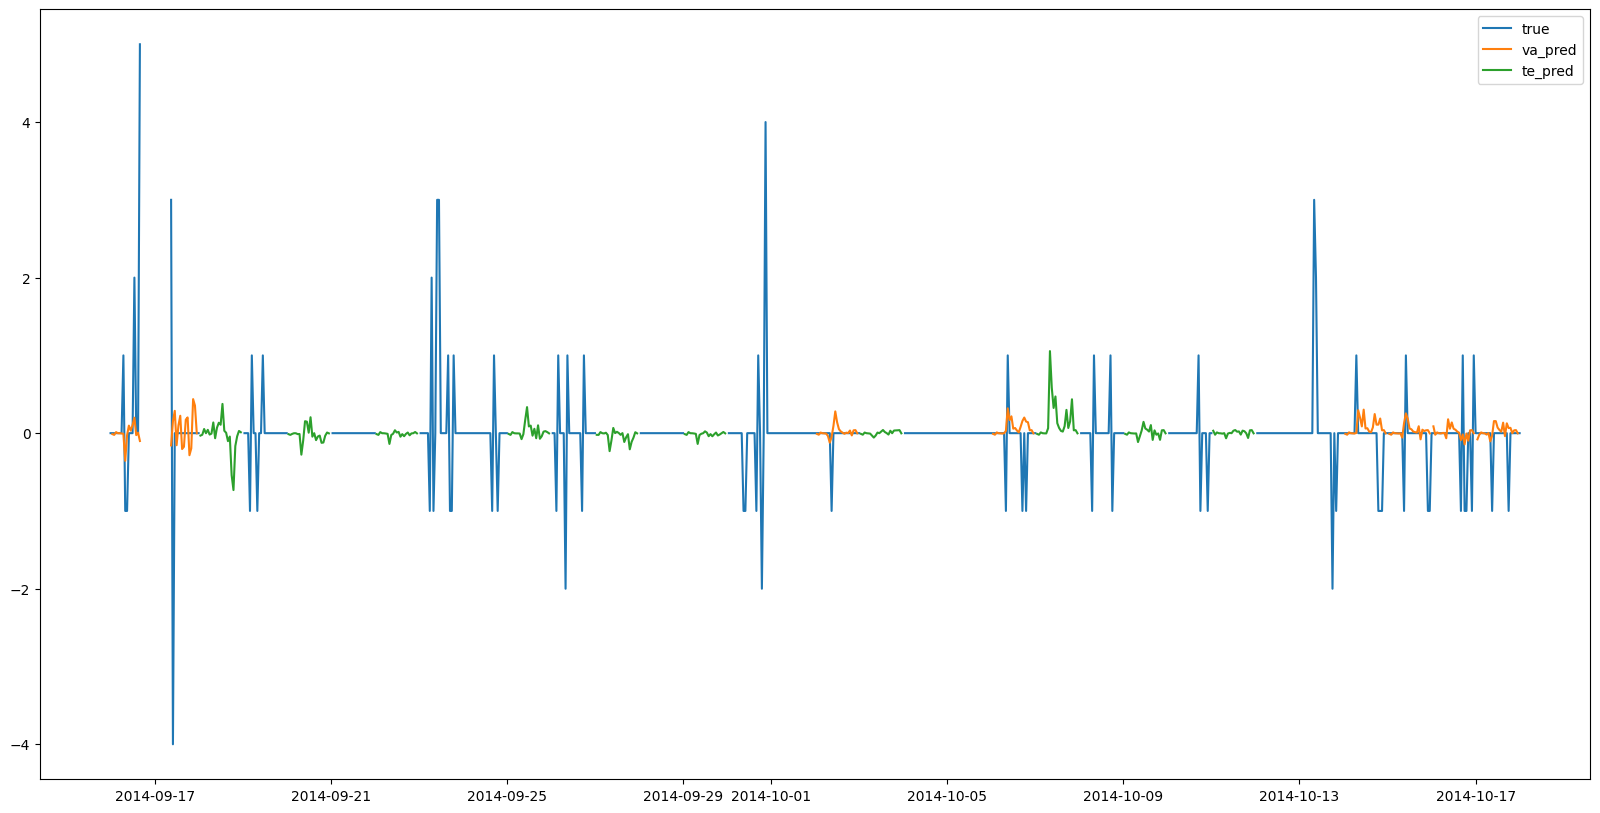

In [58]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-10-18"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}"], label="true")
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}_te_pred"], label="te_pred")
plt.legend()
plt.show()

LightGBM23期マルチモデル intervention


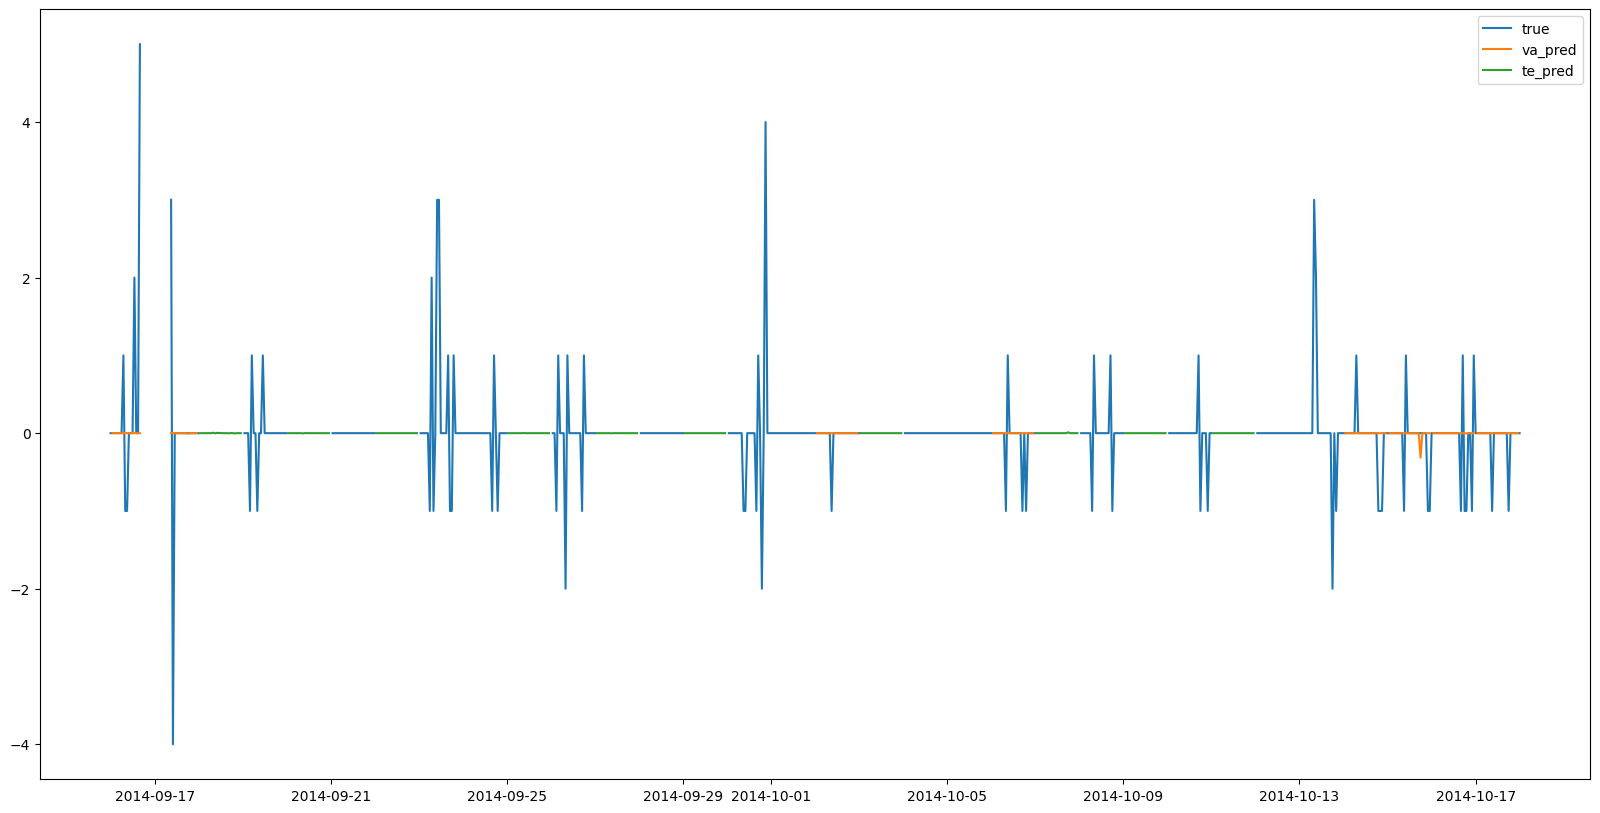

In [35]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-10-18"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}"], label="true")
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}_te_pred"], label="te_pred")
plt.legend()
plt.show()

LightGBM23期マルチモデル intervention


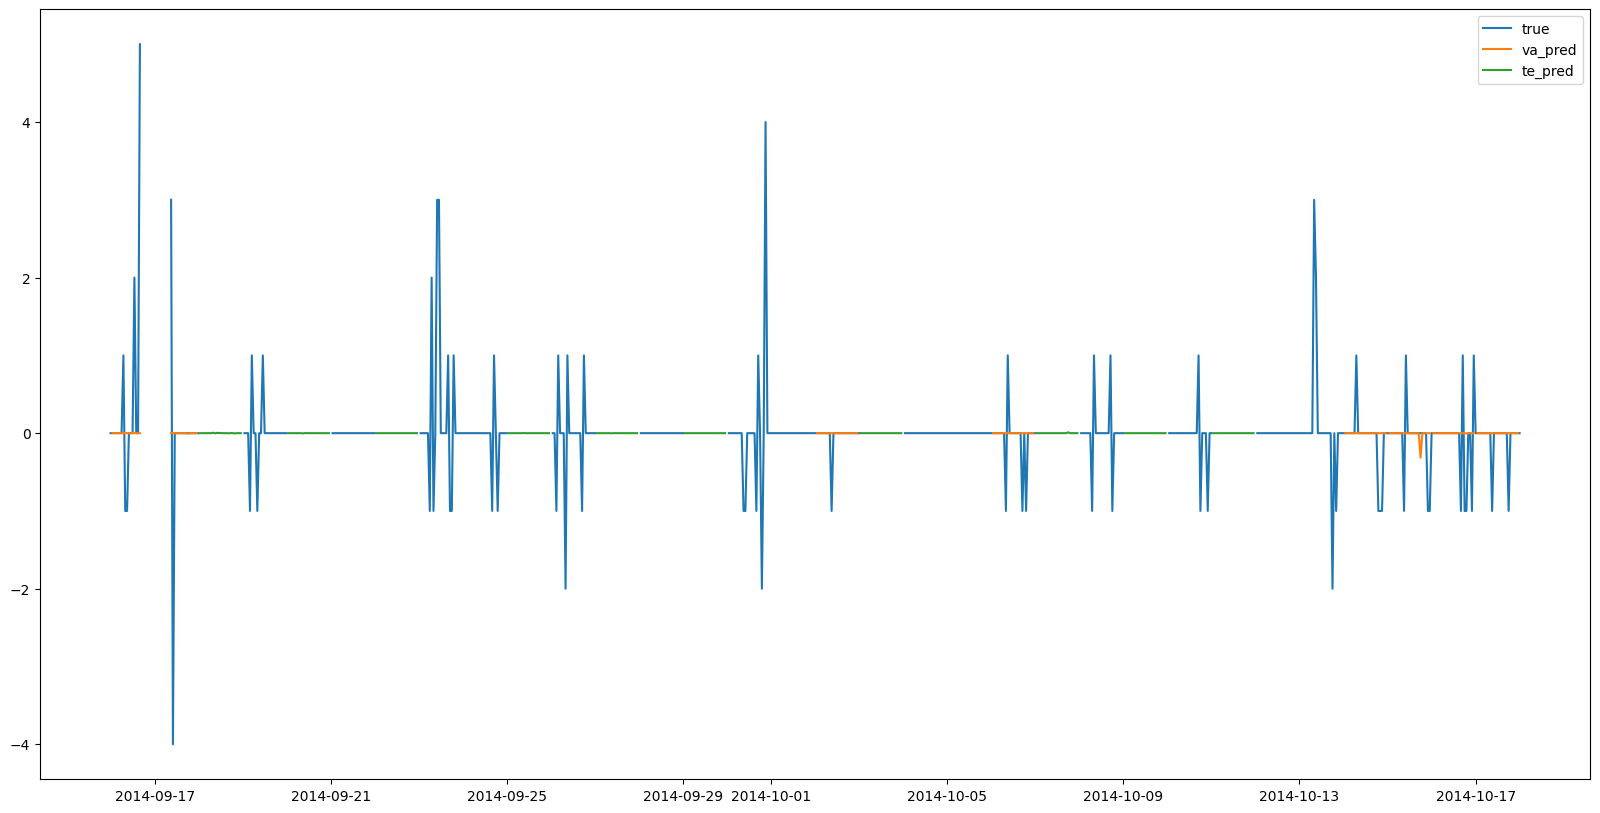

In [36]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-10-18"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}"], label="true")
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}_te_pred"], label="te_pred")
plt.legend()
plt.show()

# 需要＋供給＋介入

In [130]:
def after_predict_process(df_pred, target_col):
    """予測後に行う処理
    Args:
        df_pred(pd.DataFrame): 予測データ[key_cols, 予測値]
    """
    # 負の値を0に変換
    df_pred[target_col] = df_pred[target_col].clip(lower=0)
    # dock_countを超えないようにする
    df_prep_station = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_station.pkl"))
    df_dock_count = df_prep_station[["station_id", "dock_count"]]
    df_pred = pd.merge(df_pred, df_dock_count, on="station_id", how="left")
    df_pred[target_col] = df_pred[target_col].clip(upper=df_pred["dock_count"])
    return df_pred

In [66]:
# 各日の00:00からのcumsumに変換
def calc_cumsum_from_00(df_, col):
    df_["date"] = df_["datetime"].dt.date
    df_[f"{col}_cumsum"] = df_.groupby(["station_id", "date"])[col].cumsum()
    df_ = df_.drop(columns=[col, "date"])
    return df_

In [68]:
# de_run_name = "lgbm_multiml_demand_202410210031"
# de_va_pred = pd.read_pickle(os.path.join(DIR_MODEL, de_run_name, "va_pred.pkl"))
# de_te_pred = pd.read_pickle(os.path.join(DIR_MODEL, de_run_name, "te_pred.pkl"))
# de_va_te_pred = pd.concat([de_va_pred, de_te_pred], axis=0)

# demandをcumsumに変換
de_run_name = "lgbm_multiml_demand_202410212351"
de_va_pred = pd.read_pickle(os.path.join(DIR_MODEL, de_run_name, "va_pred.pkl"))
de_te_pred = pd.read_pickle(os.path.join(DIR_MODEL, de_run_name, "te_pred.pkl"))
de_va_te_pred = pd.concat([de_va_pred, de_te_pred], axis=0)
de_va_te_pred = calc_cumsum_from_00(de_va_te_pred, "demand")

In [69]:
su_run_name = "lgbm_multiml_supply_202410210121"
su_va_pred = pd.read_pickle(os.path.join(DIR_MODEL, su_run_name, "va_pred.pkl"))
su_te_pred = pd.read_pickle(os.path.join(DIR_MODEL, su_run_name, "te_pred.pkl"))
su_va_te_pred = pd.concat([su_va_pred, su_te_pred], axis=0)

# supplyをcumsumに変換
su_run_name = "lgbm_multiml_supply_202410220021"
su_va_pred = pd.read_pickle(os.path.join(DIR_MODEL, su_run_name, "va_pred.pkl"))
su_te_pred = pd.read_pickle(os.path.join(DIR_MODEL, su_run_name, "te_pred.pkl"))
su_va_te_pred = pd.concat([su_va_pred, su_te_pred], axis=0)
su_va_te_pred = calc_cumsum_from_00(su_va_te_pred, "supply")

In [70]:
in_run_name = "lgbm_multiml_intervention_202410210921"
in_va_pred = pd.read_pickle(os.path.join(DIR_MODEL, in_run_name, "va_pred.pkl"))
in_te_pred = pd.read_pickle(os.path.join(DIR_MODEL, in_run_name, "te_pred.pkl"))
in_va_te_pred = pd.concat([in_va_pred, in_te_pred], axis=0)

# interventionをcumsumに変換
in_run_name = "lgbm_multiml_intervention_202410220902"
in_va_pred = pd.read_pickle(os.path.join(DIR_MODEL, in_run_name, "va_pred.pkl"))
in_te_pred = pd.read_pickle(os.path.join(DIR_MODEL, in_run_name, "te_pred.pkl"))
in_va_te_pred = pd.concat([in_va_pred, in_te_pred], axis=0)
in_va_te_pred = calc_cumsum_from_00(in_va_te_pred, "intervention")


In [71]:
df_target = load_feature("df_target")
df_true_00 = df_target[df_target["datetime"].dt.hour==0][["station_id", "datetime", "bikes_available"]].copy()
df_true_00["date"] = df_true_00["datetime"].dt.date
df_true_00 = df_true_00.rename(columns={"bikes_available": "bikes_available_00"})
df_true_00 = df_true_00[["station_id", "date", "bikes_available_00"]]
df_pred = load_feature("df_key")
df_pred["date"] = df_pred["datetime"].dt.date
df_pred = pd.merge(df_pred, df_true_00, on=["station_id", "date"], how="left")
df_pred = df_pred[["station_id", "datetime", "bikes_available_00"]]

df_pred = df_pred.copy()
df_pred = pd.merge(df_pred, load_feature("df_predict_add_valid_flag"), on=["station_id","datetime"], how="left")
df_pred = pd.merge(df_pred, de_va_te_pred, on=["station_id","datetime"], how="left", suffixes=("", "_de_va_pred"))
df_pred = pd.merge(df_pred, su_va_te_pred, on=["station_id","datetime"], how="left", suffixes=("", "_su_va_pred"))
df_pred = pd.merge(df_pred, in_va_te_pred, on=["station_id","datetime"], how="left", suffixes=("", "_in_va_pred"))

df_true = df_target[["station_id", "datetime", "bikes_available"]].copy()
df_true = pd.merge(df_true, load_feature("df_predict_add_valid_flag"), on=["station_id", "datetime"], how="left")

In [72]:
df_pred["bikes_available"] = df_pred["bikes_available_00"] + df_pred["demand_cumsum"] + df_pred["supply_cumsum"] + df_pred["intervention_cumsum"]

In [73]:
df_metric = pd.merge(df_true, df_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_pred"))
df_metric = df_metric.dropna(subset=["bikes_available", "bikes_available_pred"])
df_metric = df_metric[df_metric["predict"]==2]
df_metric = df_metric.sort_values(["station_id", "datetime"])

In [75]:
from sklearn.metrics import mean_absolute_error
def metric(va_true, va_pred):
    """評価指標の計算
    """
    score = mean_absolute_error(va_true, va_pred)
    # score = math.sqrt(mean_squared_error(va_true, va_pred))

    return score

metric(df_metric["bikes_available"].values,
       df_metric["bikes_available_pred"].values)

2.552769404705002

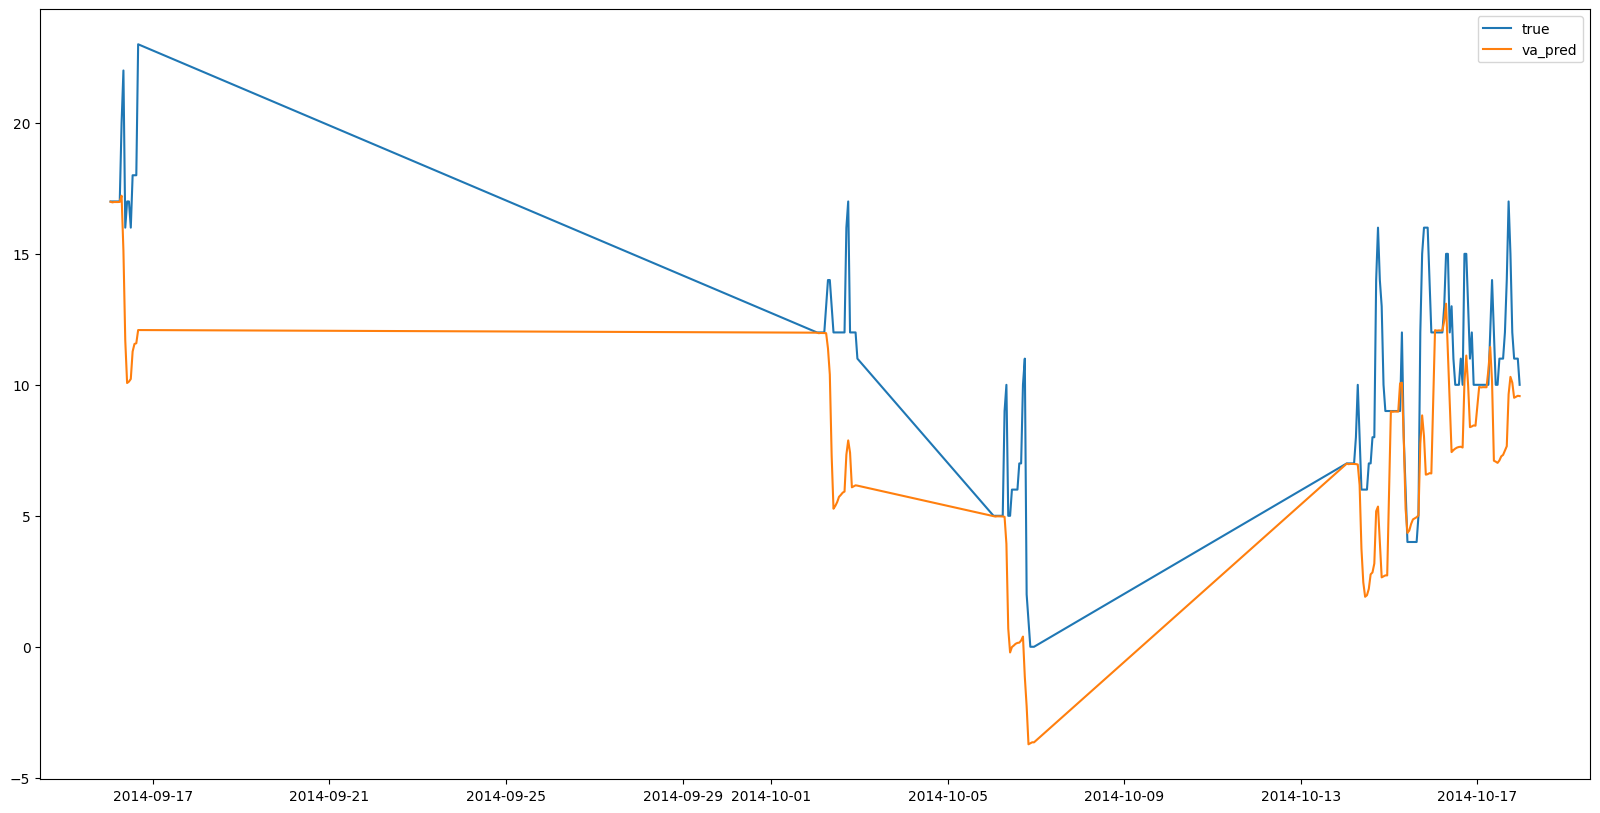

In [77]:
# datetimeを連続にする
df_ = df_metric.copy()
# データ期間,station_idを指定する
target_col = "bikes_available"
station_id = 0
start_date = "2014-09-16"
end_date = "2014-10-18"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_[f"{target_col}"], label="true")
plt.plot(df_["datetime"], df_[f"{target_col}_pred"], label="va_pred")
plt.legend()
plt.show()

# LGBM_需要＋供給＋介入

In [79]:
df_main_lgb_ans = load_feature("df_key")
df_main_lgb_ans = pd.merge(df_main_lgb_ans, load_feature("df_predict_add_valid_flag"), on=["station_id", "datetime"], how="left")
df_main_lgb_ans = pd.merge(df_main_lgb_ans, load_feature("df_bikes_available_fillna"), on=["station_id", "datetime"], how="left")
df_main_lgb_ans = pd.merge(df_main_lgb_ans, pd.read_pickle(os.path.join(DIR_FEATURE, "df_main_lgb_demand.pkl")), on=["station_id", "datetime"], how="left", suffixes=('', '_dem'))
df_main_lgb_ans = pd.merge(df_main_lgb_ans, pd.read_pickle(os.path.join(DIR_FEATURE, "df_main_lgb_supply.pkl")), on=["station_id", "datetime"], how="left", suffixes=('', '_sup'))
df_main_lgb_ans = pd.merge(df_main_lgb_ans, pd.read_pickle(os.path.join(DIR_FEATURE, "df_main_lgb_intervention.pkl")), on=["station_id", "datetime"], how="left", suffixes=('', '_int'))

In [90]:
import importlib
from src import runner
from src import model_LGBM
from src import model_ASMBL
from src import model_LSTM_mult
from src import model

# runnerモジュールをリロード
importlib.reload(runner)
importlib.reload(model_LGBM)
importlib.reload(model_ASMBL)
importlib.reload(model_LSTM_mult)
importlib.reload(model)

# Runnerクラスを再インポート
from src.model import Model
from src.runner import MLModelRunner
from src.model_LGBM import model_LGBM_multimodel
from src.model_LSTM_mult import model_LSTM_mult
from src.model_ASMBL import model_ASMBL_demand_supply_intervention

In [80]:
# ロガーの設定
logger = Logger(path=DIR_LOG)

def get_run_name(model_type):
    """run名の作成
    """
    run_name = model_type
    suffix = '_' + datetime.now().strftime("%Y%m%d%H%M")
    run_name = run_name + suffix
    return run_name

# run_nameの設定
run_name = get_run_name(model_type="ansamble_lgbm")
# run_name = 'ansamble_lgbm_202410162243'
run_name

'ansamble_lgbm_202410222022'

In [81]:
def after_pred_func(df_pred, target_col):
    """予測後に行う処理
    Args:
        df_pred(pd.DataFrame): 予測データ[key_cols, 予測値]
    """
    # 負の値を0に変換
    df_pred[target_col] = df_pred[target_col].clip(lower=0)
    # dock_countを超えないようにする
    df_prep_station = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_station.pkl"))
    df_dock_count = df_prep_station[["station_id", "dock_count"]]
    df_pred = pd.merge(df_pred, df_dock_count, on="station_id", how="left")
    df_pred[target_col] = df_pred[target_col].clip(upper=df_pred["dock_count"])
    return df_pred

model_params_lgb = {
    # run params
    "key_cols": ["datetime", "station_id"],
    "target_col": "bikes_available",
    "remove_cols": ["predict"],
    # pred model params
    "demand_model_cls": model_LGBM_multimodel,
    "supply_model_cls": model_LGBM_multimodel,
    "intervention_model_cls": model_LGBM_multimodel,
    "demand_run_name": "lgbm_multiml_demand_202410212351",
    "supply_run_name": "lgbm_multiml_supply_202410220021",
    "intervention_run_name": "lgbm_multiml_intervention_202410220902",
    # ans model run params
    "num_boost_round": 3000,
    "early_stopping_rounds": 100,
    "verbose": 1,
    "period": 100,
    # ans model core params
    "boosting_type": "gbdt",
    "objective": "regression_l1",
    "metric": "l1",
    "learning_rate": 0.01,
}
run_setting = {
    'calc_shap': False,     # shap値を計算するか否か
    'save_train_pred': False,    # trainデータに対する予測値を保存するか否か(閾値の最適化に使用)
    "tune_params": True,           # パラメータチューニング、lgb_hopt,xgb_hopt,nn_hopt,False
    "target_encoder": None, #TargetEncodingBlock(use_cache=False),     # target encodingをしない場合はNone
    "after_pred_func": after_pred_func,
}
cv_setting = {
    "key_cols": ["datetime", "station_id"],
    "target_col": "bikes_available",
    "initial_fold_date": "2014-09-01",
}

In [91]:
memo = "アンサンブルLGBM demand supply interventionの単品をcumsumに変換"
ml_runner = MLModelRunner(
    run_name,
    model_ASMBL_demand_supply_intervention,
    model_params_lgb,
    df_main_lgb_ans,
    run_setting,
    cv_setting,
    logger,
    memo)

In [92]:
ml_runner.run_train_cv()

[2024-10-22 20:44:39] - ansamble_lgbm_202410222022 - start training cv
[2024-10-22 20:44:39] - ansamble_lgbm_202410222022 fold 2014-09-01 - start training


,datetime,station_id,demand_cumsum,supply_cumsum,intervention_cumsum,bikes_available_00,lat,long,dock_count,installation_date,...,city_city4,city_city5,datetime_feat,year,month,day,hour,weekday,holiday,bikes_available
460318,2014-06-28 20:00:00,0,-3.530243e-01,7.044438,-0.054095,11.0,37.32973,-121.90178,27,20130806,...,0,0,20140628,2014,6,28,20,5,1,11.0
460388,2014-06-28 21:00:00,0,-3.621390e-01,7.044438,-0.005294,11.0,37.32973,-121.90178,27,20130806,...,0,0,20140628,2014,6,28,21,5,1,11.0
460458,2014-06-28 22:00:00,0,-3.621390e-01,7.044438,0.010072,11.0,37.32973,-121.90178,27,20130806,...,0,0,20140628,2014,6,28,22,5,1,10.0
460528,2014-06-28 23:00:00,0,-3.621390e-01,7.044438,0.007665,11.0,37.32973,-121.90178,27,20130806,...,0,0,20140628,2014,6,28,23,5,1,10.0
460598,2014-06-29 01:00:00,0,0.000000e+00,0.000000,-0.508113,11.0,37.32973,-121.90178,27,20130806,...,0,0,20140629,2014,6,29,1,6,1,10.0
460667,2014-06-29 02:00:00,0,0.000000e+00,0.000000,-0.531609,11.0,37.32973,-121.90178,27,20130806,...,0,0,20140629,2014,6,29,2,6,1,10.0
460736,2014-06-29 03:00:00,0,0.000000e+00,0.000000,-0.517973,11.0,37.32973,-121.90178,27,20130806,...,0,0,20140629,2014,6,29,3,6,1,10.0
460805,2014-06-29 04:00:00,0,0.000000e+00,0.000000,-0.518755,11.0,37.32973,-121.90178,27,20130806,...,0,0,20140629,2014,6,29,4,6,1,10.0
460874,2014-06-29 05:00:00,0,0.000000e+00,0.000000,-0.489863,11.0,37.32973,-121.90178,27,20130806,...,0,0,20140629,2014,6,29,5,6,1,11.0
460943,2014-06-29 06:00:00,0,0.000000e+00,0.000000,-0.491904,11.0,37.32973,-121.90178,27,20130806,...,0,0,20140629,2014,6,29,6,6,1,10.0


,datetime,station_id,demand_cumsum,supply_cumsum,intervention_cumsum,bikes_available_00,lat,long,dock_count,installation_date,...,city_city4,city_city5,datetime_feat,year,month,day,hour,weekday,holiday,bikes_available
560046,2014-08-29 20:00:00,0,-11.370636,12.660105,3.378706,7.0,37.32973,-121.90178,27,20130806,...,0,0,20140829,2014,8,29,20,4,0,6.0
560116,2014-08-29 21:00:00,0,-11.370573,12.660105,3.468624,7.0,37.32973,-121.90178,27,20130806,...,0,0,20140829,2014,8,29,21,4,0,6.0
560186,2014-08-29 22:00:00,0,-11.370573,12.660105,3.502332,7.0,37.32973,-121.90178,27,20130806,...,0,0,20140829,2014,8,29,22,4,0,6.0
560256,2014-08-29 23:00:00,0,-11.370573,12.660105,3.499925,7.0,37.32973,-121.90178,27,20130806,...,0,0,20140829,2014,8,29,23,4,0,6.0
560326,2014-08-30 01:00:00,0,0.000000,0.000000,-0.010009,5.0,37.32973,-121.90178,27,20130806,...,0,0,20140830,2014,8,30,1,5,1,5.0
560396,2014-08-30 02:00:00,0,0.000000,0.000000,-0.032213,5.0,37.32973,-121.90178,27,20130806,...,0,0,20140830,2014,8,30,2,5,1,5.0
560466,2014-08-30 03:00:00,0,0.000000,0.000000,-0.018577,5.0,37.32973,-121.90178,27,20130806,...,0,0,20140830,2014,8,30,3,5,1,5.0
560536,2014-08-30 04:00:00,0,0.000000,0.000000,-0.019204,5.0,37.32973,-121.90178,27,20130806,...,0,0,20140830,2014,8,30,4,5,1,5.0
560606,2014-08-30 05:00:00,0,0.000000,0.000000,-0.022118,5.0,37.32973,-121.90178,27,20130806,...,0,0,20140830,2014,8,30,5,5,1,5.0
560676,2014-08-30 06:00:00,0,0.000000,0.040872,-0.088953,5.0,37.32973,-121.90178,27,20130806,...,0,0,20140830,2014,8,30,6,5,1,5.0


(463772, 24) (463772,) (99774, 24) (99774,)


,demand_cumsum,supply_cumsum,intervention_cumsum,bikes_available_00,lat,long,dock_count,installation_date,station_id_feat,installation_year,...,city_city3,city_city4,city_city5,datetime_feat,year,month,day,hour,weekday,holiday
463742,-33.254775,13.792904,-0.925047,21.0,37.79539,-122.39420,23,20130820,39,2013,...,0,0,0,20140630,2014,6,30,23,0,0
463743,-15.723542,1.109909,2.381032,5.0,37.79146,-122.39103,19,20130820,40,2013,...,0,0,0,20140630,2014,6,30,23,0,0
463744,-17.965762,1.572778,-0.440172,11.0,37.78387,-122.40843,19,20130825,41,2013,...,0,0,0,20140630,2014,6,30,23,0,0
463745,-17.766126,12.370498,0.845626,11.0,37.78715,-122.38801,15,20130820,42,2013,...,0,0,0,20140630,2014,6,30,23,0,0
463746,-31.124616,1.100297,-0.065807,20.0,37.78976,-122.39464,23,20130820,43,2013,...,0,0,0,20140630,2014,6,30,23,0,0
463747,-18.620537,0.010582,4.992583,5.0,37.79225,-122.39709,19,20130820,44,2013,...,0,0,0,20140630,2014,6,30,23,0,0
463748,-15.278420,5.136519,-1.150111,9.0,37.78175,-122.40513,15,20130821,45,2013,...,0,0,0,20140630,2014,6,30,23,0,0
463749,-8.504938,0.215725,0.108603,13.0,37.78133,-122.41860,23,20130821,47,2013,...,0,0,0,20140630,2014,6,30,23,0,0
463750,-28.123765,24.171436,-3.895751,5.0,37.80477,-122.40323,15,20130821,48,2013,...,0,0,0,20140630,2014,6,30,23,0,0
463751,-29.953472,12.379149,2.090965,5.0,37.78053,-122.39029,27,20130822,49,2013,...,0,0,0,20140630,2014,6,30,23,0,0


...

,demand_cumsum,supply_cumsum,intervention_cumsum,bikes_available_00,lat,long,dock_count,installation_date,station_id_feat,installation_year,...,city_city3,city_city4,city_city5,datetime_feat,year,month,day,hour,weekday,holiday
594106,-16.502687,3.907009e+00,-0.836603,12.0,37.79146,-122.39103,19,20130820,40,2013,...,0,0,0,20140929,2014,9,29,23,0,0
594107,-20.907822,1.217161e+01,0.628554,7.0,37.78387,-122.40843,19,20130825,41,2013,...,0,0,0,20140929,2014,9,29,23,0,0
594108,-15.236949,5.436584e+00,0.113345,11.0,37.78715,-122.38801,15,20130820,42,2013,...,0,0,0,20140929,2014,9,29,23,0,0
594109,-34.617248,1.710363e+00,-0.760996,18.0,37.78976,-122.39464,23,20130820,43,2013,...,0,0,0,20140929,2014,9,29,23,0,0
594110,-20.762822,9.798620e-03,5.856020,4.0,37.79225,-122.39709,19,20130820,44,2013,...,0,0,0,20140929,2014,9,29,23,0,0
594111,-14.509176,7.147415e+00,0.367701,5.0,37.78175,-122.40513,15,20130821,45,2013,...,0,0,0,20140929,2014,9,29,23,0,0
594112,-3.891048,1.179667e-02,0.811554,7.0,37.77865,-122.41824,19,20130821,46,2013,...,0,0,0,20140929,2014,9,29,23,0,0
594113,-7.591108,-7.768194e-07,3.518332,4.0,37.78133,-122.41860,23,20130821,47,2013,...,0,0,0,20140929,2014,9,29,23,0,0
594114,-26.925537,1.781267e+00,0.359474,7.0,37.80477,-122.40323,15,20130821,48,2013,...,0,0,0,20140929,2014,9,29,23,0,0
594115,-32.479343,7.367882e+00,1.157720,7.0,37.78053,-122.39029,27,20130822,49,2013,...,0,0,0,20140929,2014,9,29,23,0,0


594106   NaN
594107   NaN
594108   NaN
594109   NaN
594110   NaN
594111   NaN
594112   NaN
594113   NaN
594114   NaN
594115   NaN
594116   NaN
594117   NaN
594118   NaN
594119   NaN
594120   NaN
594121   NaN
594122   NaN
594123   NaN
594124   NaN
594125   NaN
594126   NaN
594127   NaN
594128   NaN
594129   NaN
594130   NaN
594131   NaN
594132   NaN
594133   NaN
594134   NaN
594135   NaN
Name: bikes_available, dtype: float64

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016544 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1386
[LightGBM] [Info] Number of data points in the train set: 513682, number of used features: 24
[LightGBM] [Info] Start training from score 8.000000
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 1.97579	eval's l1: 3.38568
[200]	train's l1: 1.69884	eval's l1: 3.13265
[300]	train's l1: 1.55792	eval's l1: 3.0172
[400]	train's l1: 1.50876	eval's l1: 2.97755
[500]	train's l1: 1.48893	eval's l1: 2.96462
[600]	train's l1: 1.4789	eval's l1: 2.9593
[700]	train's l1: 1.47223	eval's l1: 2.95689
[800]	train's l1: 1.47012	eval's l1: 2.95509
[900]	train's l1: 1.46945	eval's l1: 2.95424
[1000]	train's l1: 1.46865	eval's l1: 2.95399
[1100]	train's l1: 1.4684	eval's l1: 2.95391
[1200]	train's l1: 1.46829	eval's l1: 

[2024-10-22 20:48:56] - ansamble_lgbm_202410222022 fold 2014-10-01 - end training
[2024-10-22 20:48:56] - ansamble_lgbm_202410222022 fold 2014-11-01 - start training


KeyboardInterrupt: 

In [149]:
ml_runner.run_metric_cv()

[2024-10-21 21:09:18] - ansamble_lgbm_202410210959 - start metric cv
  0%|          | 0/12 [00:00<?, ?it/s]

2014-09-01 00:00:00
(9660, 3)
(9660, 3)
(9660, 3)
(9660, 25)


  8%|▊         | 1/12 [00:40<07:28, 40.78s/it]

(8680, 3) (8680, 4)
2014-10-01 00:00:00
(9660, 3)
(9660, 3)
(9660, 3)
(9660, 25)


 17%|█▋        | 2/12 [01:21<06:44, 40.46s/it]

(9660, 3) (9660, 4)
2014-11-01 00:00:00
(11270, 3)
(11270, 3)
(11270, 3)
(11270, 25)


 25%|██▌       | 3/12 [02:05<06:19, 42.22s/it]

(11270, 3) (11270, 4)
2014-12-01 00:00:00


 25%|██▌       | 3/12 [02:20<07:01, 46.81s/it]


KeyboardInterrupt: 

In [121]:
ml_runner.run_predict_cv()

[2024-10-21 10:43:32] - ansamble_lgbm_202410210959 - start prediction cv
  0%|          | 0/12 [00:00<?, ?it/s]

(16100, 3)
(16100, 3)
(16100, 3)
(16100, 25)


  8%|▊         | 1/12 [00:41<07:41, 41.99s/it]

(16100, 3)
(16100, 3)
(16100, 3)
(16100, 25)


 17%|█▋        | 2/12 [01:20<06:38, 39.88s/it]

...

 83%|████████▎ | 10/12 [06:29<01:18, 39.39s/it]

(16100, 3)
(16100, 3)
(16100, 3)
(14490, 25)


 92%|█████████▏| 11/12 [07:08<00:39, 39.42s/it]

(16100, 3)
(16100, 3)
(16100, 3)
(16100, 25)


100%|██████████| 12/12 [07:47<00:00, 38.97s/it]
[2024-10-21 10:51:20] - output predict : ../models/ansamble_lgbm_202410210959/te_pred.pkl
[2024-10-21 10:51:20] - ansamble_lgbm_202410210959 - end prediction cv


In [150]:
ml_runner.plot_feature_importance_cv()

[2024-10-21 21:11:41] - ansamble_lgbm_202410210959 - start plot feature importance cv
[2024-10-21 21:12:11] - ansamble_lgbm_202410210959 - end plot feature importance cv


In [141]:
path_va_pred = os.path.join(ml_runner.out_dir_name, "va_pred.pkl")
path_te_pred = os.path.join(ml_runner.out_dir_name, "te_pred.pkl")
df_va_pred = pd.read_pickle(path_va_pred)
df_te_pred = pd.read_pickle(path_te_pred)

df_true = pd.read_pickle(os.path.join(DIR_INTERIM, "status_data.pkl"))[ml_runner.key_cols+[ml_runner.target_col]]

アンサンブルLGBM ベースライン


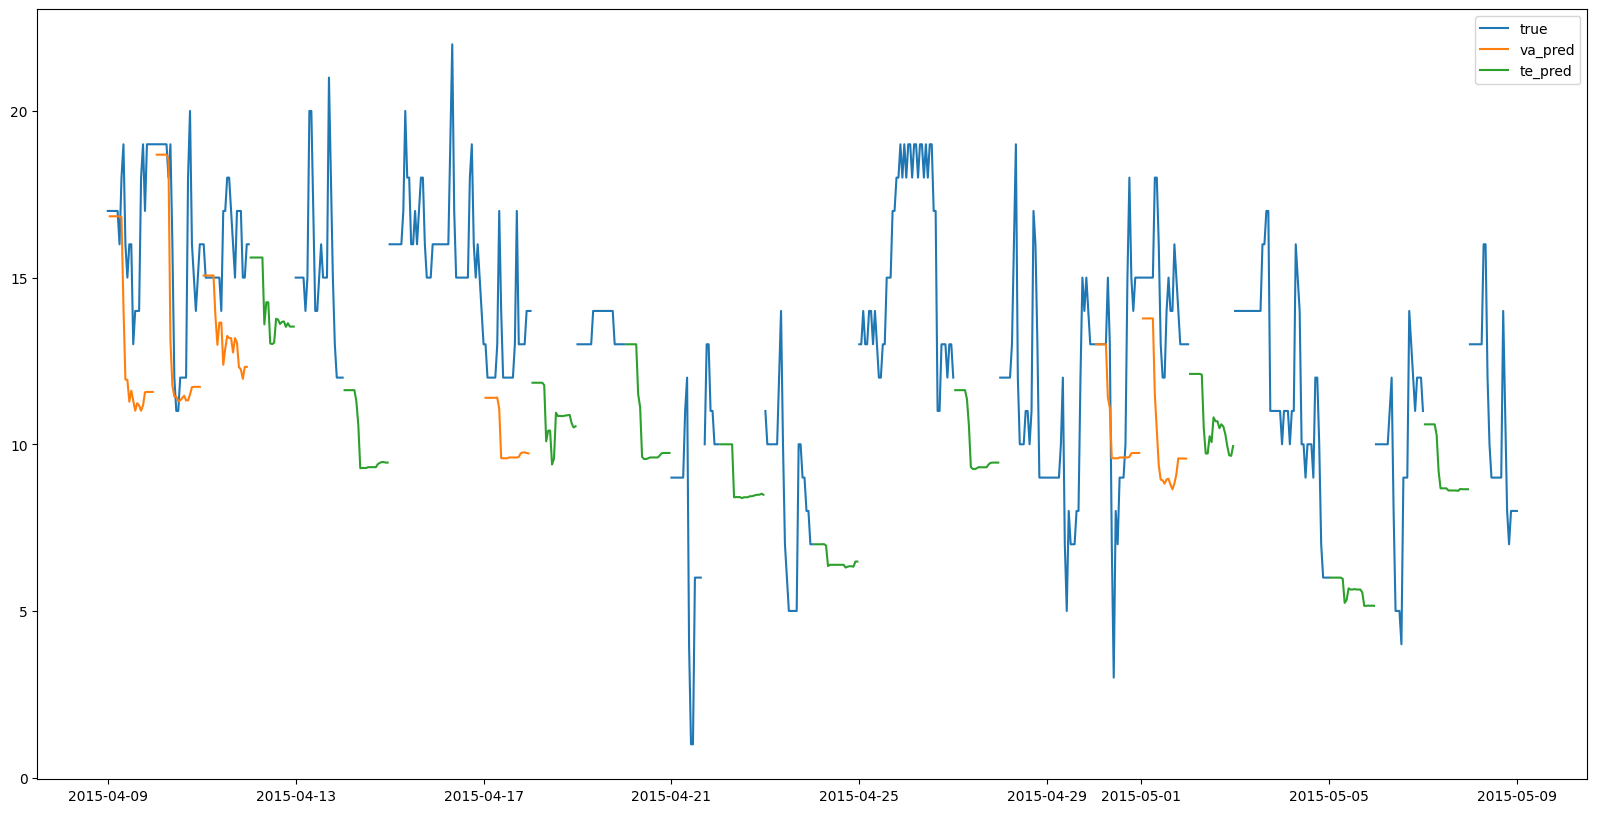

In [142]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2015-04-09"
end_date = "2015-05-09"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_["bikes_available"], label="true")
plt.plot(df_["datetime"], df_["bikes_available_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_["bikes_available_te_pred"], label="te_pred")
plt.legend()
plt.show()

アンサンブルLGBM ベースライン


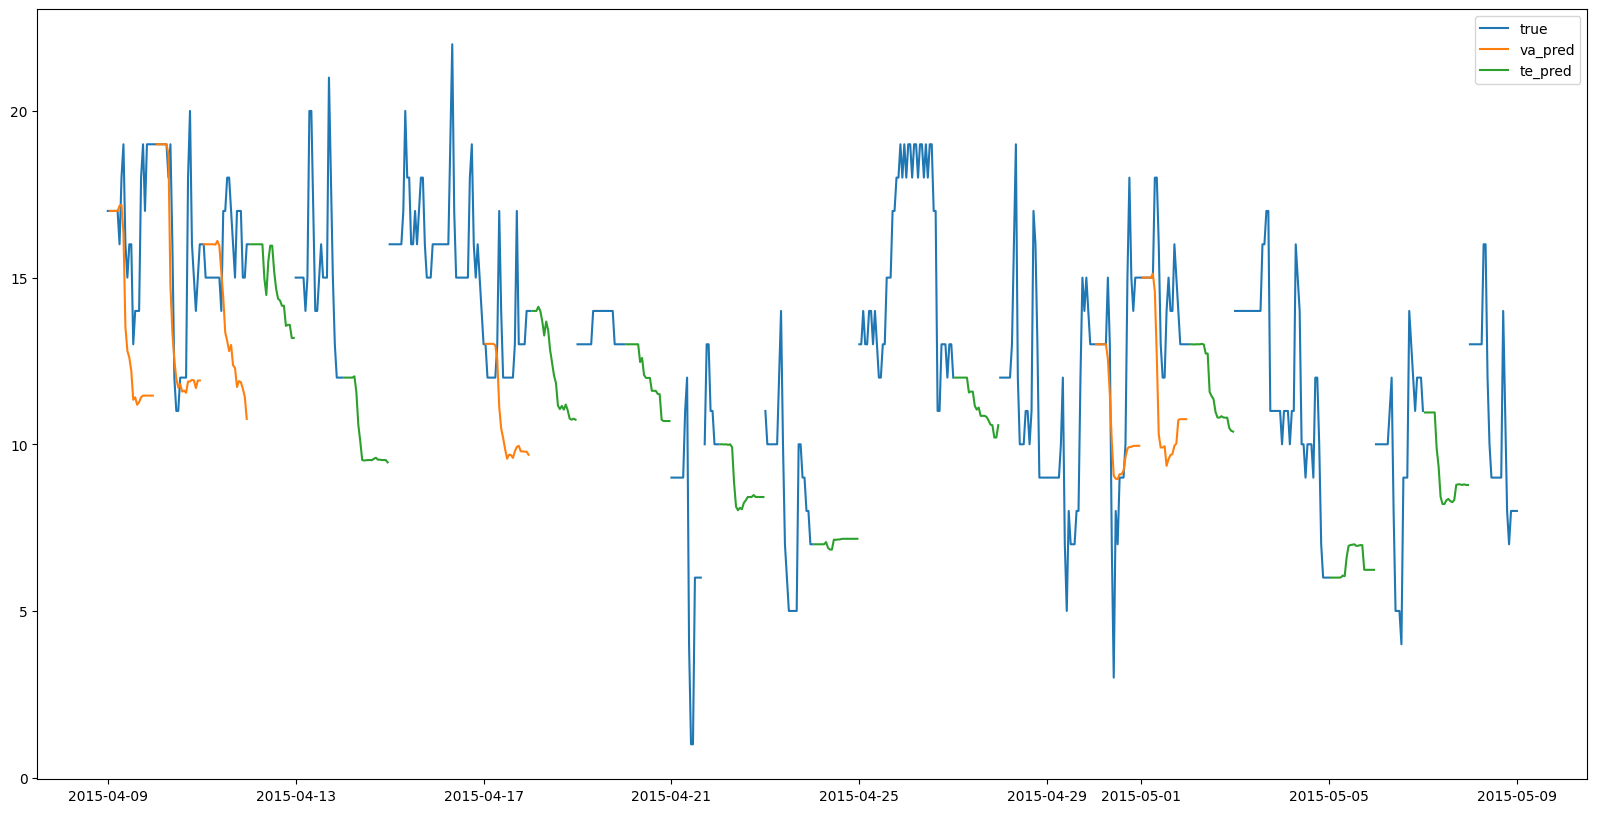

In [ ]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2015-04-09"
end_date = "2015-05-09"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_["bikes_available"], label="true")
plt.plot(df_["datetime"], df_["bikes_available_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_["bikes_available_te_pred"], label="te_pred")
plt.legend()
plt.show()

# Submissionの作成

In [45]:
runner = ml_runner

In [46]:
path_te_pred = os.path.join(runner.out_dir_name, "te_pred.pkl")
df_te_pred = pd.read_pickle(path_te_pred)
df_prep_status = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_status.pkl"))[["id", "datetime", "station_id", "predict"]]

In [47]:
df_submit = pd.merge(df_prep_status, df_te_pred, on=["datetime", "station_id"], how="left")

In [48]:
df_sample_submit = pd.read_csv(os.path.join(DIR_INPUT, "sample_submit.csv"), header=None, names=["id", "b_a"])
df_submit = pd.merge(df_sample_submit, df_submit, on=["id"], how="left")[["id", "bikes_available"]]
path_submit = os.path.join(DIR_SUBMISSION, f"{runner.run_name}_submit.csv")
df_submit.to_csv(path_submit, header=False, index=False)
print(path_submit)

../data/submission/lgbm_multimodel_bikes_202410242029_submit.csv


In [49]:
pd.read_csv(path_submit, header=None)

,0,1
0,8761,14.998344
1,8762,14.985830
2,8763,14.990958
3,8764,14.968130
4,8765,14.993657
...,...,...
193195,1226347,9.924549
193196,1226348,9.757839
193197,1226349,9.878020
193198,1226350,10.286882
